# Inference and Analysis of Cell-Cell Communication using CellChat

**Corresponds to:** R vignette `CellChat-vignette.Rmd` by Suoqin Jin  
**Python package:** `cellchat` (v1.1, 100% function coverage of R API)  
**Dataset:** `data_humanSkin.h5` 鈥?Human skin scRNA-seq, LS (lesional/diseased) condition  
**Purpose:** Run the full CellChat pipeline in Python and compare results against the R reference output

## Setup & Imports

In [1]:
import os, sys, time, pickle, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
%matplotlib inline

# Import the package from this repository when the notebook runs from the project or tutorial directory.
project_root = Path(os.getcwd()).resolve().parent if Path(os.getcwd()).name == "tutorial" else Path(os.getcwd()).resolve()
if (project_root / "CellChatPy").is_dir():
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
import CellChatPy as cc
import CellChatPy.analysis as cc_analysis
print(f"Using CellChat from: {cc.__file__}")
print(f"Using CellChat analysis from: {cc_analysis.__file__}")

# Create one stable output directory regardless of the notebook working directory.
OUT_DIR = (project_root / "tutorial" / "figures_vignette").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures will be saved to: {OUT_DIR}")

def save_fig(fig, name):
    """Validate, save, display, and close one Matplotlib figure."""
    if fig is None:
        print(f"  [SKIP] {name} returned None")
        return None
    path = Path(OUT_DIR) / name

    try:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    except OSError as exc:
        raise OSError(
            f"Could not save figure to {str(path)!r}: "
            f"{type(exc).__name__}: {exc}"
        ) from exc

    print(f"  Saved: {path}")
    plt.show()
    plt.close(fig)

    # Do not return fig, otherwise Jupyter displays the same figure again.
    return None

print(f"CellChat version: {cc.__version__ if hasattr(cc, '__version__') else 'dev'}")

Using CellChat from: E:\Jin\cellchat.python_new\CellChatPy\__init__.py
Using CellChat analysis from: E:\Jin\cellchat.python_new\CellChatPy\analysis.py
Figures will be saved to: E:\Jin\cellchat.python_new\tutorial\figures_vignette
CellChat version: 1.1.0


---
## Part I: Data Input & Processing and Initialization of CellChat Object

Corresponds to R vignette Part I: Load normalized scRNA-seq data, subset to LS condition, create CellChat object, set ligand-receptor database, and preprocess expression data.

In [2]:
ptm_total = time.time()
ptm = time.time()

# --- Load data from HDF5 ---
data_path = project_root / "data" / "data_humanSkin.h5"
if not data_path.is_file():
    raise FileNotFoundError(f"Input HDF5 file not found: {data_path}")
print(f"Loading {data_path} ...")
with h5py.File(data_path, "r") as f:
    dim       = f["data/dim"][:]
    indices   = f["data/indices"][:]
    indptr    = f["data/indptr"][:]
    values    = f["data/values"][:]
    genes     = [g.decode() for g in f["genes"][:]]
    cells     = [c.decode() for c in f["cells"][:]]
    condition = [c.decode() for c in f["meta/condition"][:]]
    labels    = [c.decode() for c in f["meta/labels"][:]]
    rownames  = [c.decode() for c in f["meta/rownames"][:]]
    patient   = [c.decode() for c in f["meta/patient.id"][:]]

n_rows, n_cols = int(dim[0]), int(dim[1])
mat = sp.csc_matrix((values, indices, indptr), shape=(n_rows, n_cols))

meta_all = pd.DataFrame(
    {"patient.id": patient, "condition": condition, "labels": labels},
    index=rownames,
)

# Subset to LS (lesional) condition
ls_cells = meta_all[meta_all["condition"] == "LS"].index.tolist()
ls_idx   = [cells.index(c) for c in ls_cells]

# CellChatPy uses cells x genes, while this HDF5 matrix is genes x cells.
# Subset columns first, then transpose so rows align with metadata cells.
mat_ls = mat[:, ls_idx].T.tocsr()
meta = meta_all.loc[ls_cells].copy()

# Match the R vignette factor levels exactly. The HDF5 file stores labels as
# plain strings, so pandas would otherwise sort categories alphabetically and
# break alignment with the source R vignette cell-group order.
r_cell_levels = [
    "APOE+ FIB", "FBN1+ FIB", "COL11A1+ FIB", "Inflam. FIB",
    "cDC1", "cDC2", "LC", "Inflam. DC",
    "TC", "Inflam. TC", "CD40LG+ TC", "NKT",
]
missing_levels = sorted(set(meta["labels"].unique()) - set(r_cell_levels))
if missing_levels:
    raise ValueError(f"Unexpected cell labels not present in R levels: {missing_levels}")
meta["labels"] = pd.Categorical(meta["labels"], categories=r_cell_levels, ordered=True)
meta["cellchat_group"] = meta["labels"]
observed_levels = [lvl for lvl in r_cell_levels if (meta["labels"] == lvl).any()]

print(f"  Genes: {len(genes):,} | Cells (LS): {mat_ls.shape[0]:,}")
print(f"  Cell labels (R level order): {observed_levels}")
print(f"Load elapsed: {time.time()-ptm:.1f}s")

Loading E:\Jin\cellchat.python_new\data\data_humanSkin.h5 ...
  Genes: 17,328 | Cells (LS): 5,011
  Cell labels (R level order): ['APOE+ FIB', 'FBN1+ FIB', 'COL11A1+ FIB', 'Inflam. FIB', 'cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC', 'NKT']
Load elapsed: 0.8s


In [3]:
# --- Create CellChat object ---
cellchat = cc.create_cellchat(
    object=mat_ls,      # scipy sparse matrix (cells x genes)
    metadata=meta,
    group_by="cellchat_group",
    genes=genes,        # Matrix columns are genes
    cells=ls_cells       # Matrix rows are the LS cell names
)

# Guard against accidentally losing the R factor level order.
if list(cellchat.groups.categories) != r_cell_levels:
    raise AssertionError(
        "CellChat identities do not match the R vignette level order: "
        f"{list(cellchat.groups.categories)}"
    )

print(f"Cell groups: {list(cellchat.groups.categories)}")
print(f"var_names[0]: {cellchat.var_names[0]}")
print(f"data_signaling initialized: {cellchat.signaling is not None}")

Create a CellChat object from a data matrix
Cell groups used for CellChat analysis: ['APOE+ FIB', 'FBN1+ FIB', 'COL11A1+ FIB', 'Inflam. FIB', 'cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC', 'NKT']
Cell groups: ['APOE+ FIB', 'FBN1+ FIB', 'COL11A1+ FIB', 'Inflam. FIB', 'cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC', 'NKT']
var_names[0]: A1BG
data_signaling initialized: True


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\00_database_category.png


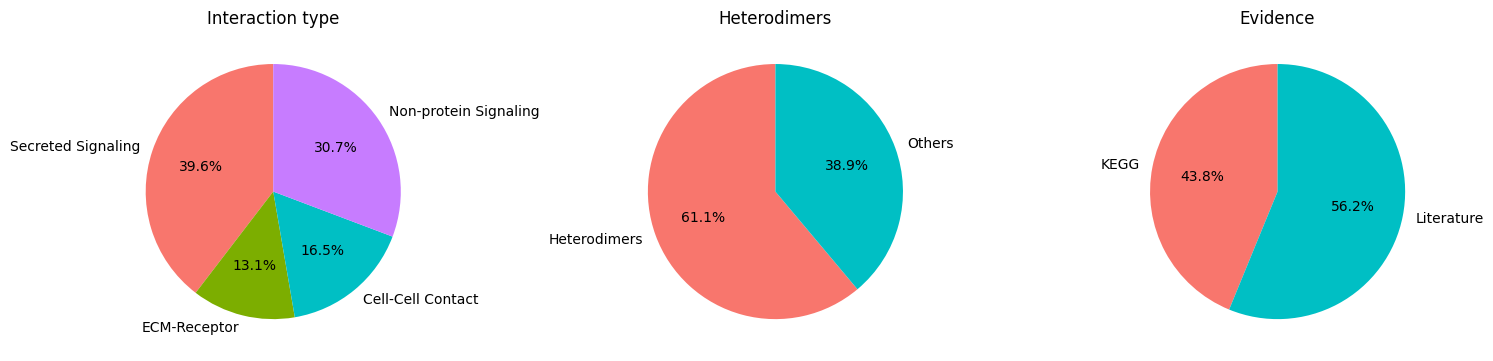

Full database: 3233 interactions
Using subset: Secreted Signaling only
  Subset interactions: 1280


In [4]:
#  Load CellChat database

# Load full database
db_full = cc.load_database(species="human")

# Visualize full database composition (before subsetting)
fig = cc.show_database_category(db_full)
save_fig(fig, "00_database_category.png")

# Subset to "Secreted Signaling" only (matching R tutorial)
# This excludes ECM-Receptor, Cell-Cell Contact, and Non-protein Signaling
db_subset = cc.subset_database(db_full, search="Secreted Signaling", key="annotation")

# Assign subset to cellchat
cellchat.database = db_subset

print(f"Full database: {len(db_full['interaction'])} interactions")
print(f"Using subset: Secreted Signaling only")
print(f"  Subset interactions: {len(db_subset['interaction'])}")

In [5]:
#  Preprocess expression data

print("=== Preprocessing ===")

# Step 1: Subset to signaling genes
cellchat = cc.subset_signaling_data(cellchat)
signaling_view = cellchat.signaling
if sp.issparse(signaling_view):
    signaling_nan_count = int(np.isnan(signaling_view.data).sum())
else:
    signaling_nan_count = int(np.isnan(np.asarray(signaling_view)).sum())
if signaling_nan_count:
    raise ValueError(
        f"Signaling expression contains {signaling_nan_count:,} NaN values. "
        "Scipy sparse zero entries may have been converted to NaN."
    )
print(
    f"1. subset_signaling_data: {int(cellchat.var['is_signaling'].sum())} signaling genes; "
    f"layer shape={signaling_view.shape} (cells x genes); "
    f"NaN={signaling_nan_count}"
)

# Step 2: Identify over-expressed genes
cellchat = cc.identify_overexpressed_genes(cellchat)
sig_genes = cellchat.feature_results.get('features', [])
print(f"2. identify_overexpressed_genes: {len(sig_genes)} significant genes")

# Step 3: Identify over-expressed LR interactions (creates cellchat.lr_pairs)
cellchat = cc.identify_overexpressed_interactions(cellchat)
lr_pairs = cellchat.lr_pairs.get('significant', pd.DataFrame())
print(f"3. identify_overexpressed_interactions: {len(lr_pairs)} LR pairs")

# Sanity check
if len(lr_pairs) == 0:
    print("\nERROR: 0 LR pairs detected!")
    print(f"  - Significant genes: {len(sig_genes)}")
    print(f"  - Database loaded: {'interaction' in cellchat.database}")
    print(f"  - signaling view shape: {signaling_view.shape if signaling_view is not None else None}")
    raise ValueError("Cannot proceed without LR pairs. Check upstream steps.")
else:
    print(f"\nPreprocessing complete. Ready for compute_communication_probability.")

=== Preprocessing ===
1. subset_signaling_data: 594 signaling genes; layer shape=(5011, 17328) (cells x genes); NaN=0
2. identify_overexpressed_genes: 523 significant genes
The number of highly variable ligand-receptor pairs used for signaling inference is 688
3. identify_overexpressed_interactions: 688 LR pairs

Preprocessing complete. Ready for compute_communication_probability.


---
## Part II: Inference of Cell-Cell Communication Network

Compute communication probabilities, filter, aggregate to pathway level, and calculate aggregated networks.

In [6]:
ptm = time.time()

# --- Compute communication probability ---
# Use R-exported permutations to match R's set.seed(1); sample.int(...) bootstrap p-values.
r_perm_path = project_root / "r_permutations.csv"
permutation_use = None
if r_perm_path.exists():
    permutation_use = pd.read_csv(r_perm_path).to_numpy(dtype=int) - 1  # R is 1-based, Python is 0-based
    print(f"Using R permutation matrix: {r_perm_path}")

cellchat = cc.compute_communication_probability(cellchat, type_method="triMean", permutation_use=permutation_use)
print(f"compute_communication_probability elapsed: {time.time()-ptm:.1f}s")

# --- Filter communication ---
cellchat = cc.filter_communication(cellchat, min_cells=10)

# --- Extract inferred network as DataFrame ---
df_net = cc.subset_communication(cellchat)
print(f"\nSignificant L-R interactions: {len(df_net)}")
display(df_net.head(10))

Using R permutation matrix: E:\Jin\cellchat.python_new\r_permutations.csv
triMean is used for calculating the average gene expression per cell group.
Using externally supplied permutation matrix (5011 x 100).
Pre-computing 100 bootstrap averaged expressions...
Computing communication probabilities for 688 LR pairs...
>>> CellChat inference is done.
Results stored in .network.
compute_communication_probability elapsed: 123.4s

Significant L-R interactions: 367


,source,target,ligand,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,evidence
0,APOE+ FIB,APOE+ FIB,FGF7,FGFR1,0.006276,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358
1,APOE+ FIB,FBN1+ FIB,FGF7,FGFR1,0.009363,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358
2,APOE+ FIB,COL11A1+ FIB,FGF7,FGFR1,0.007386,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358
3,APOE+ FIB,Inflam. FIB,FGF7,FGFR1,0.008251,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358
4,FBN1+ FIB,APOE+ FIB,FGF7,FGFR1,0.004855,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358
5,FBN1+ FIB,FBN1+ FIB,FGF7,FGFR1,0.007247,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358
6,FBN1+ FIB,COL11A1+ FIB,FGF7,FGFR1,0.005715,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358
7,FBN1+ FIB,Inflam. FIB,FGF7,FGFR1,0.006385,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358
8,COL11A1+ FIB,APOE+ FIB,FGF7,FGFR1,0.003576,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358
9,COL11A1+ FIB,FBN1+ FIB,FGF7,FGFR1,0.005341,0.0,FGF7_FGFR1,FGF7 - FGFR1,FGF,Secreted Signaling,PMC: 4393358


In [7]:
#  Compute pathway-level communication
cellchat = cc.compute_pathway_probability(cellchat)
pathways = list(cellchat.pathway_network["prob"])
print(f"Significant pathways ({len(pathways)}): {pathways}")

#  Calculate aggregated cell-cell communication network
cellchat = cc.aggregate_network(cellchat, thresh=0.051)  # Slightly relaxed to match R boundary behavior

elapsed = time.time() - ptm
print(f"  Part II elapsed: {elapsed:.1f} s")

Pathway-level results stored in .pathway_network.
Significant pathways (16): ['MIF', 'ANNEXIN', 'CypA', 'GALECTIN', 'CXCL', 'COMPLEMENT', 'FGF', 'TNF', 'CCL', 'GAS', 'IL4', 'CD40', 'IGFBP', 'LIGHT', 'CSF', 'VEGF']


  Part II elapsed: 123.6 s


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\01_circle_count.png


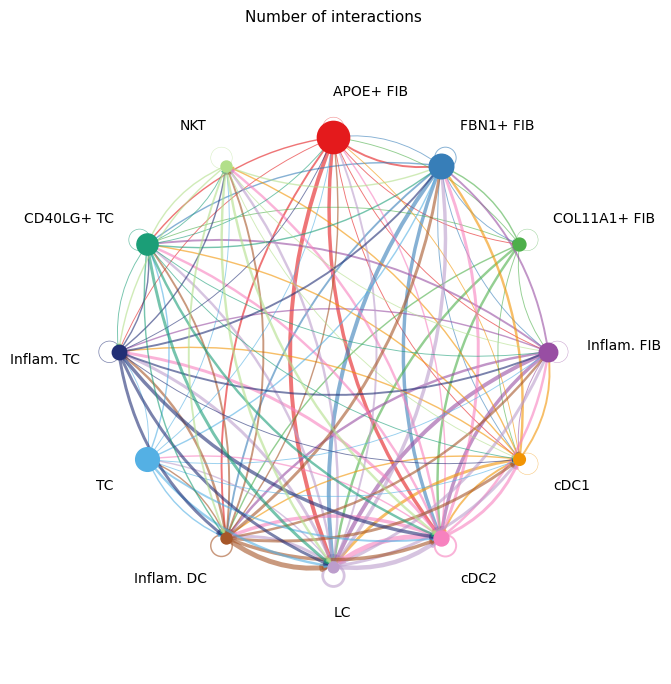

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_weight.png


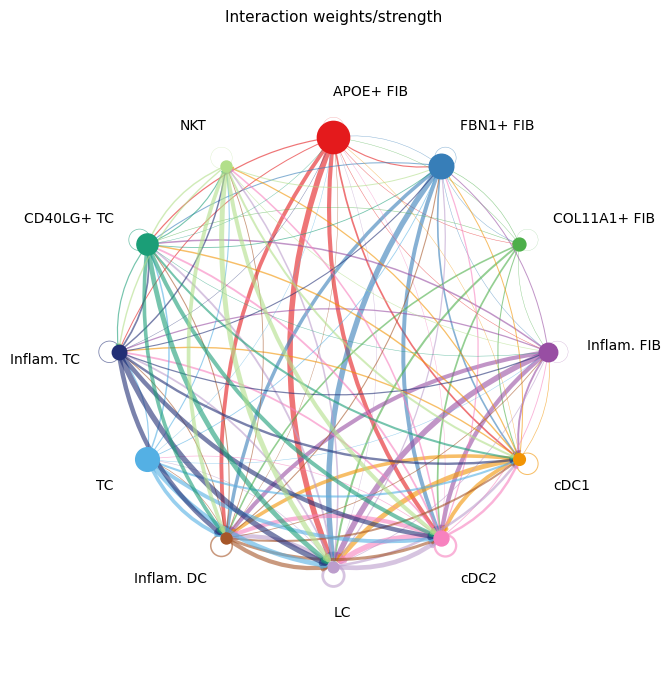

In [8]:
#  Visualize aggregated network: Circle plot

cluster_names = list(cellchat.groups.categories)
group_size = [int((cellchat.groups == g).sum()) for g in cluster_names]

# Number of interactions
fig = cc.plot_network_circle(
    cellchat, net_matrix=cellchat.network["count"].astype(float),
    vertex_weight=group_size, weight_scale=True,
    title_name="Number of interactions", return_fig=True)
save_fig(fig, "01_circle_count.png")

# Interaction weights/strength
fig = cc.plot_network_circle(
    cellchat, net_matrix=cellchat.network["weight"].astype(float),
    vertex_weight=group_size, weight_scale=True,
    title_name="Interaction weights/strength", return_fig=True)
save_fig(fig, "02_circle_weight.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_APOEplus_FIB_out.png


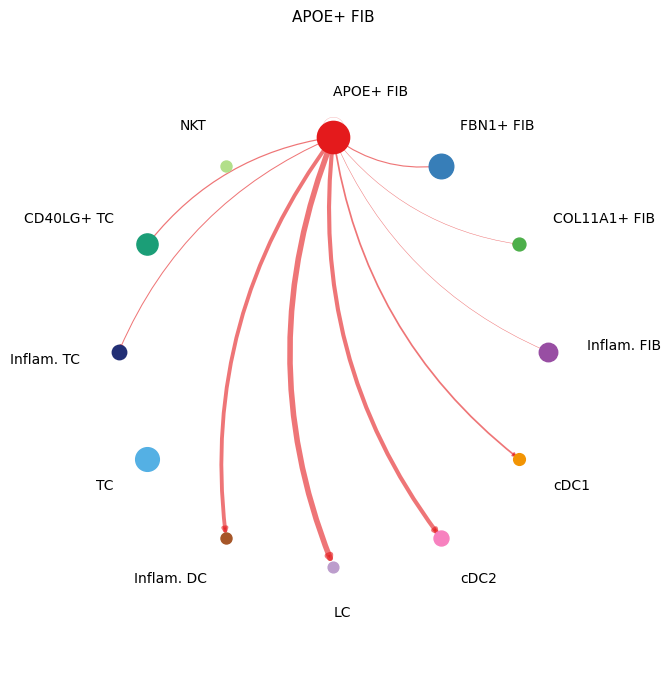

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_FBN1plus_FIB_out.png


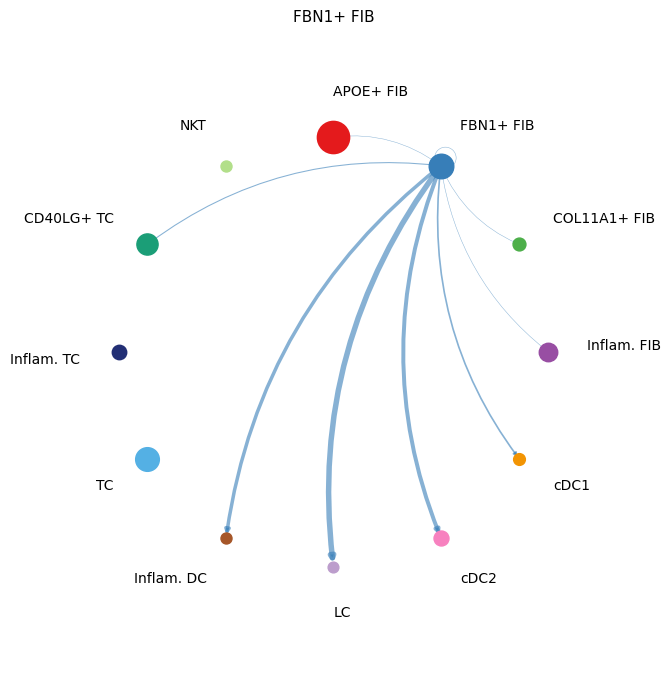

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_COL11A1plus_FIB_out.png


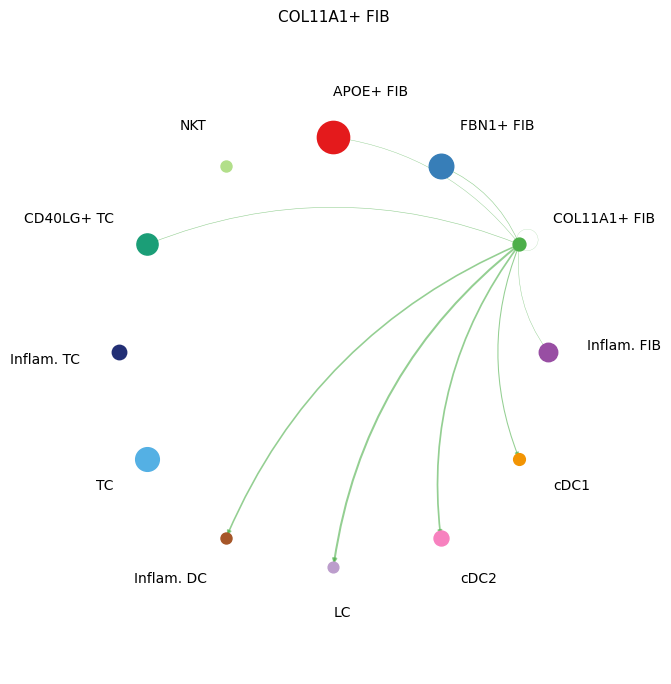

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_Inflam._FIB_out.png


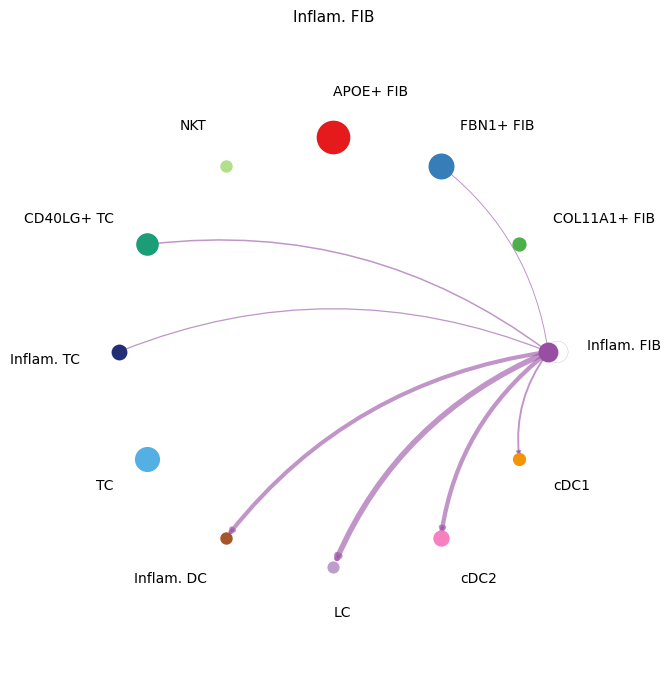

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_cDC1_out.png


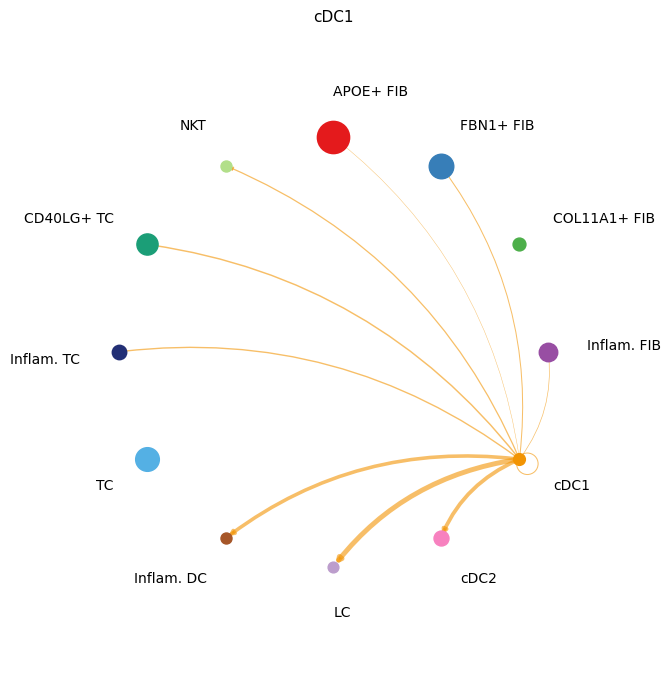

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_cDC2_out.png


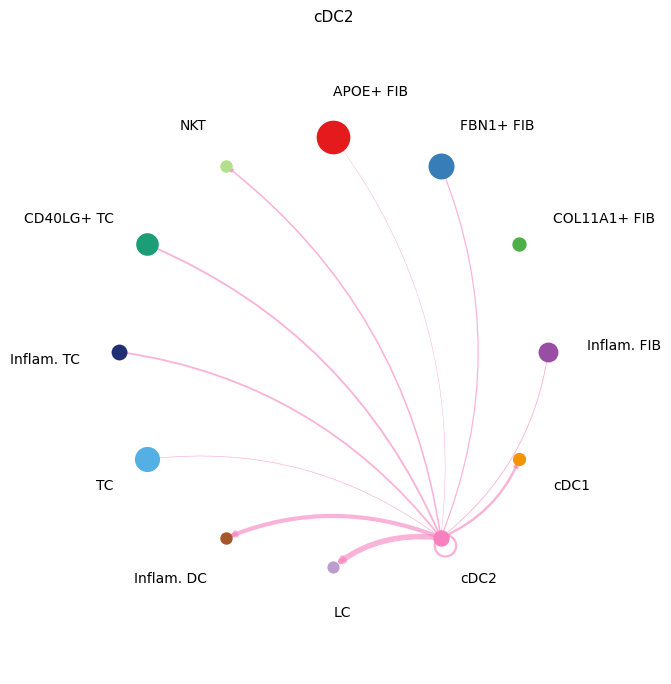

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_LC_out.png


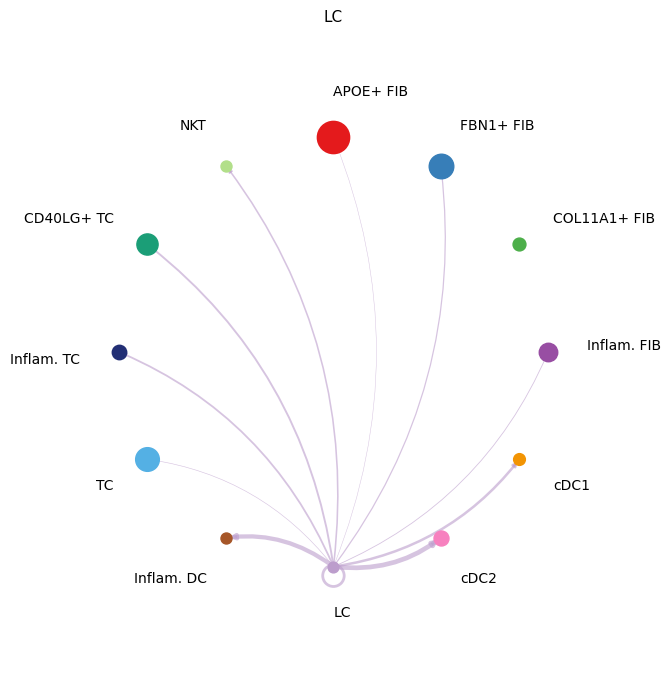

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_Inflam._DC_out.png


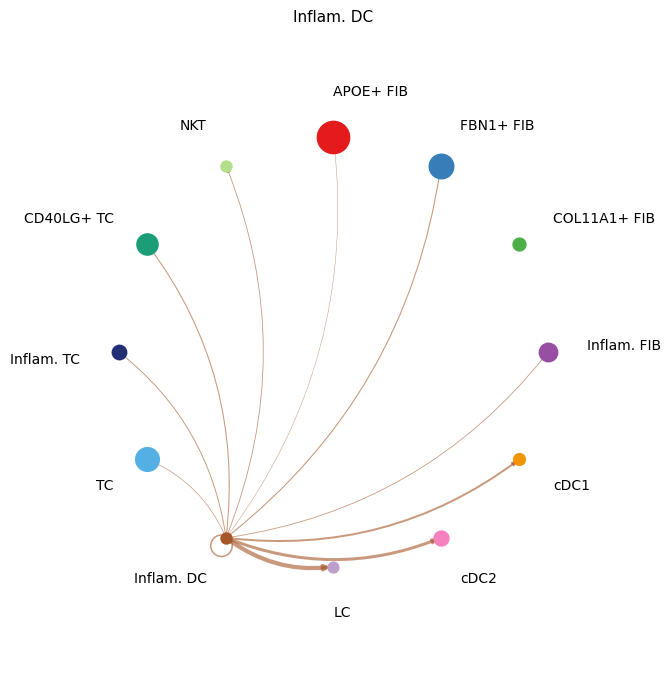

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_TC_out.png


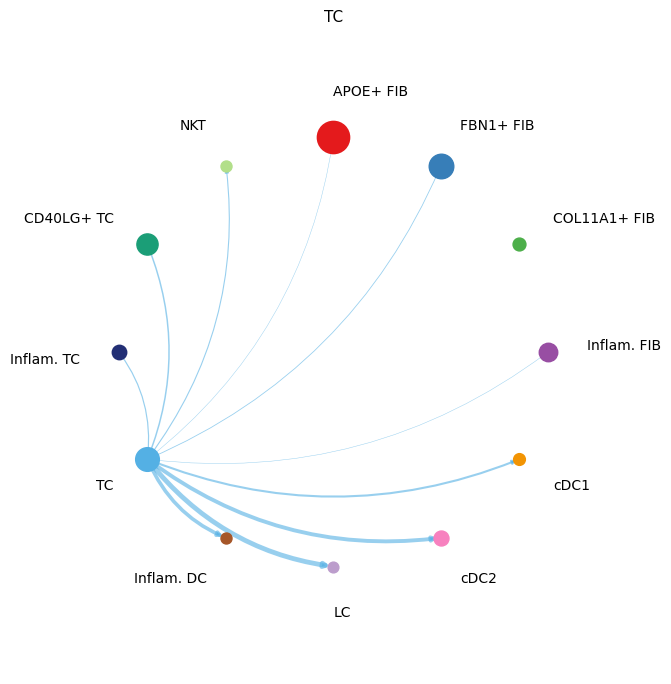

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_Inflam._TC_out.png


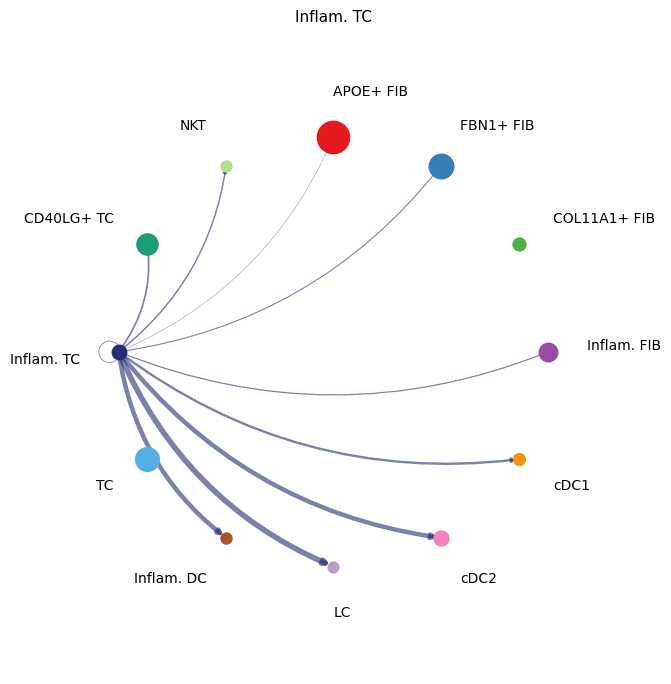

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_CD40LGplus_TC_out.png


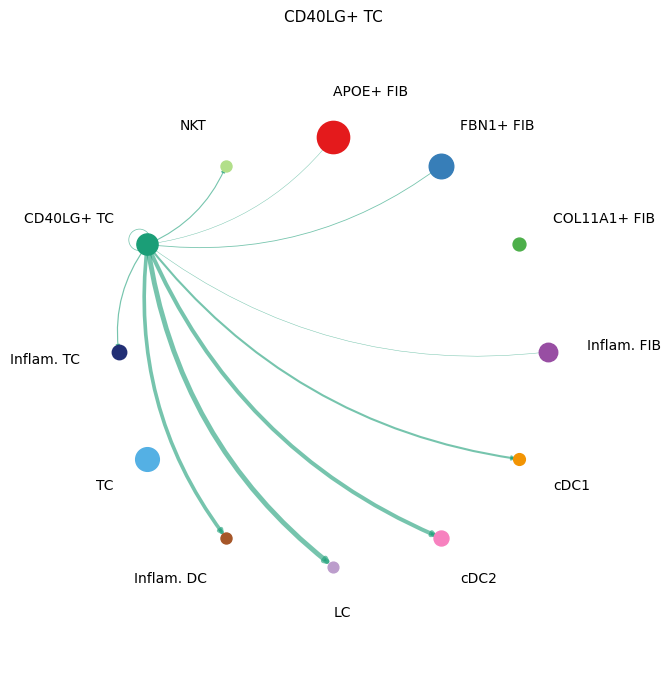

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\02_circle_NKT_out.png


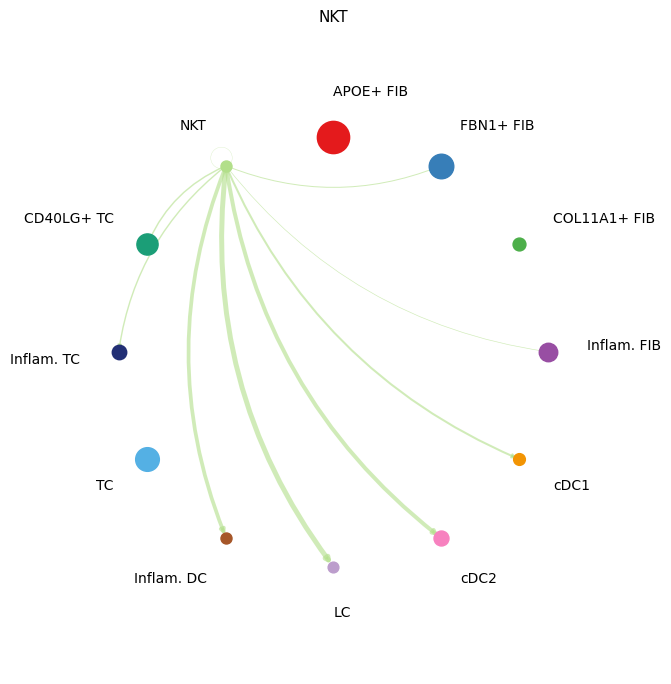

In [9]:
#  Visualize signaling from each cell group
# Note: Use 'weight' (communication strength) not 'count' to match R tutorial
weight_mat = cellchat.network["weight"].astype(float)
for i, grp in enumerate(cluster_names):
    mat_out = np.zeros_like(weight_mat)
    mat_out[i, :] = weight_mat[i, :]
    safe = grp.replace(" ", "_").replace("/", "_").replace("+", "plus")
    fig = cc.plot_network_circle(
        cellchat, net_matrix=mat_out, vertex_weight=group_size,
        edge_weight_max=weight_mat.max(), title_name=grp, return_fig=True)
    save_fig(fig, f"02_circle_{safe}_out.png")

---
## Part III: Visualization of Cell-Cell Communication Network

Visualize each signaling pathway using hierarchy/circle/chord/heatmap plots, bubble plots, chord gene diagrams, and violin plots.

--- CXCL ---
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\03_circle_CXCL.png


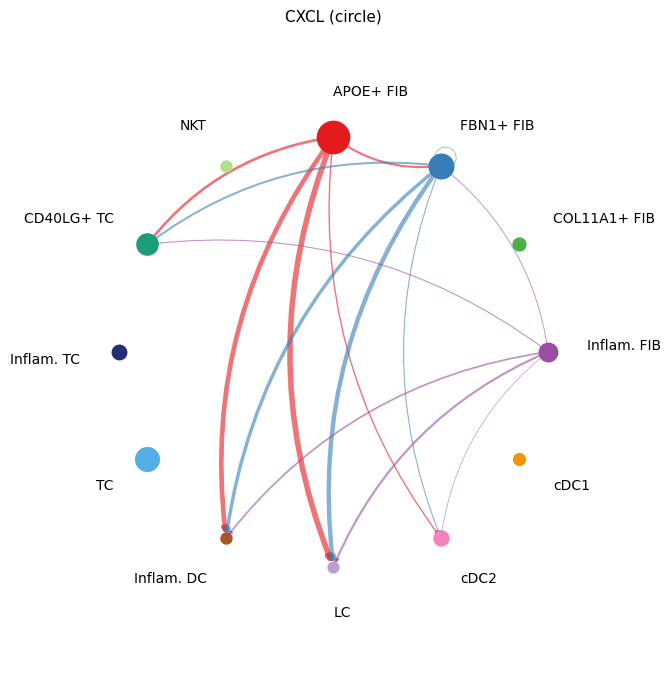

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\03_heatmap_CXCL.png


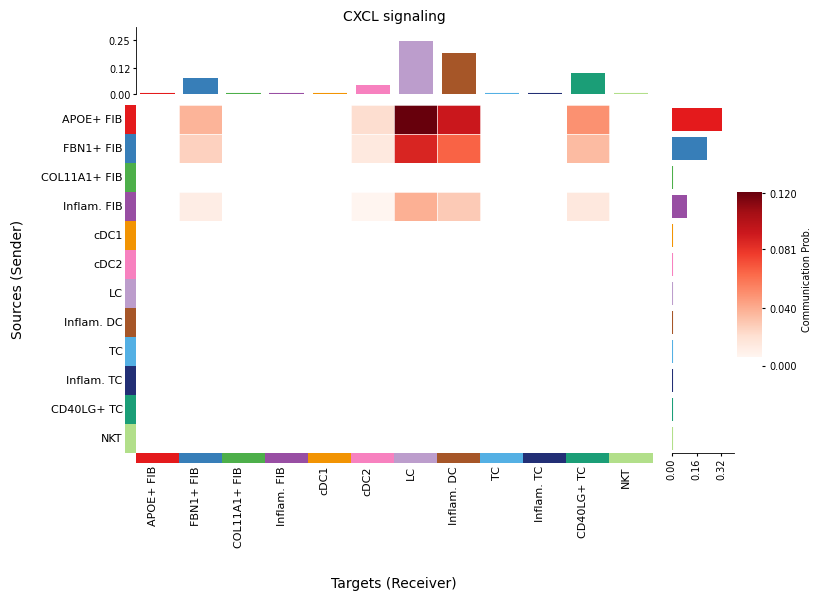

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\03_chord_cell_CXCL.png


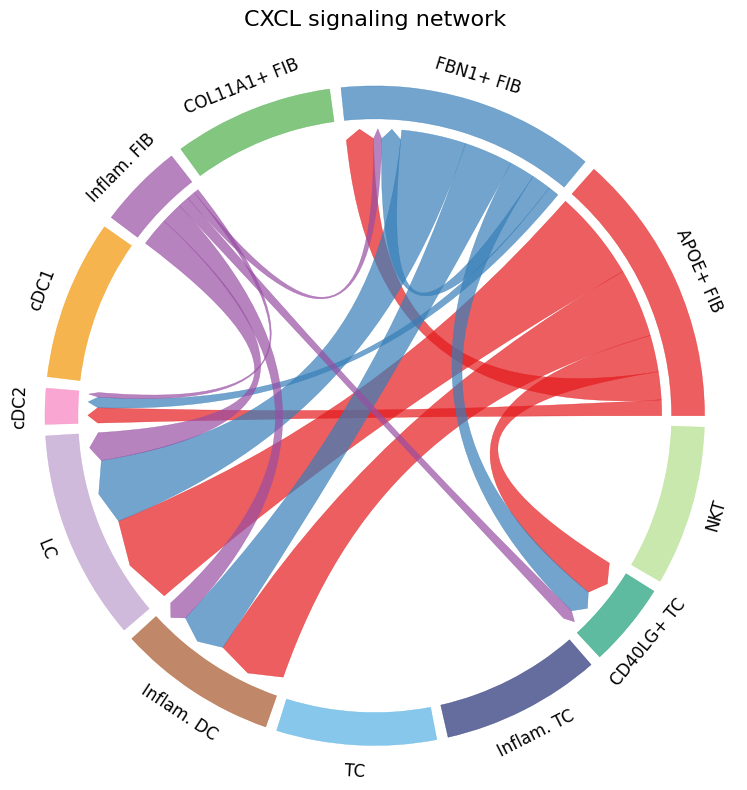

  Part III elapsed: 1.4 s


In [10]:
ptm = time.time()
#  Single pathway visualization: CXCL
pathways_show = ["CXCL"]
for pw in pathways_show:
    safe = pw.replace(" ", "_")
    print(f"--- {pw} ---")
    # Circle plot
    fig = cc.plot_network_circle(
        cellchat, slot_name="pathway_network", signaling=pw,
        vertex_weight=group_size, title_name=f"{pw} (circle)", return_fig=True)
    save_fig(fig, f"03_circle_{safe}.png")
    # Heatmap
    fig = cc.plot_network_heatmap(
        cellchat, signaling=pw, color_heatmap="Reds",
        title_name=f"{pw} signaling", return_fig=True)
    save_fig(fig, f"03_heatmap_{safe}.png")
    # Chord diagram (cell level)
    fig = cc.plot_network_chord_cell(
        cellchat, signaling=pw,
        title_name=f"{pw} signaling network",
        return_fig=True)
    save_fig(fig, f"03_chord_cell_{safe}.png")
elapsed = time.time() - ptm
print(f"  Part III elapsed: {elapsed:.1f} s")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\04_contribution_CXCL.png


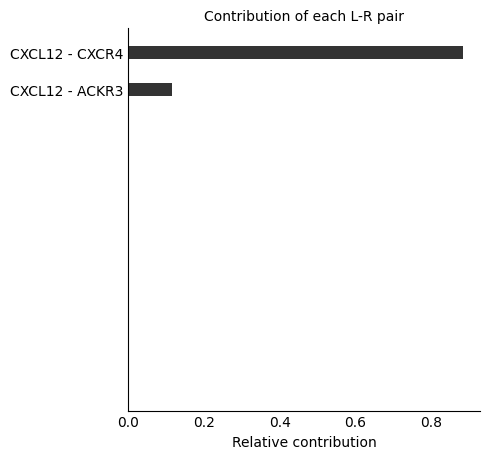

In [11]:
#  Contribution of each L-R pair to the overall signaling pathway
for pw in pathways_show:
    safe = pw.replace(" ", "_")
    fig = cc.plot_analysis_contribution(cellchat, signaling=pw, return_fig=True)
    save_fig(fig, f"04_contribution_{safe}.png")

CXCL enriched L-R pairs:


,interaction_name
0,CXCL12_CXCR4
1,CXCL12_ACKR3


  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\05_individual_CXCL_circle.png


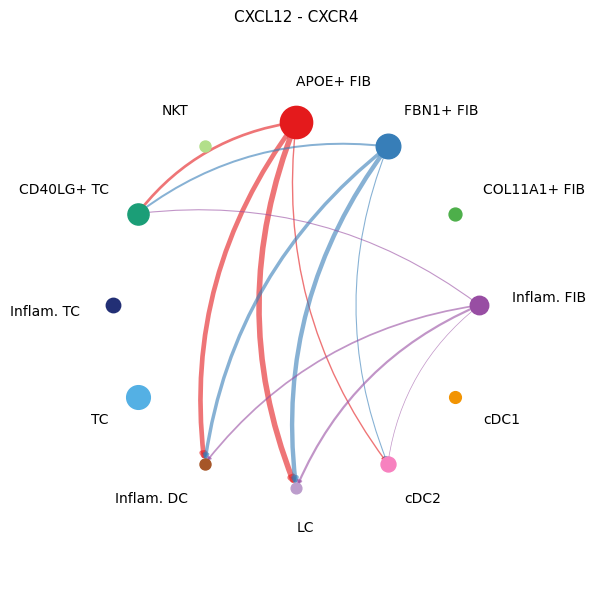

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\05_individual_CXCL_chord.png


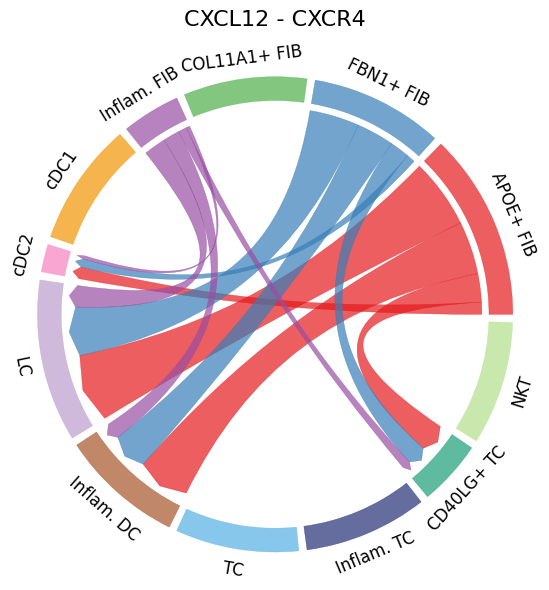

In [12]:
#  Individual L-R pair visualization
for pw in pathways_show:
    safe = pw.replace(" ", "_")
    pair_lr = cc.extract_enriched_lr(cellchat, signaling=[pw], gene_lr_return=False)
    if pair_lr is not None and len(pair_lr) > 0:
        print(f"{pw} enriched L-R pairs:")
        display(pair_lr.head(5))
        lr_show = [pair_lr.iloc[0]["interaction_name"]]
        lr_title = lr_show[0].replace("_", " - ")
        # Circle plot for the first L-R pair
        fig = cc.plot_network_individual(
            cellchat, signaling=pw, pair_lr_use=lr_show,
            layout="circle", title_name=lr_title, return_fig=True)
        save_fig(fig, f"05_individual_{safe}_circle.png")
        # Chord diagram for the first L-R pair
        fig = cc.plot_network_individual(
            cellchat, signaling=pw, pair_lr_use=lr_show,
            layout="chord", title_name=lr_title, return_fig=True)
        save_fig(fig, f"05_individual_{safe}_chord.png")

Selected source group -> ['Inflam. FIB']
Selected target groups -> ['cDC1', 'cDC2', 'LC', 'Inflam. DC', 'TC', 'Inflam. TC', 'CD40LG+ TC']
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\06_bubble_src4_tgt5to11.png


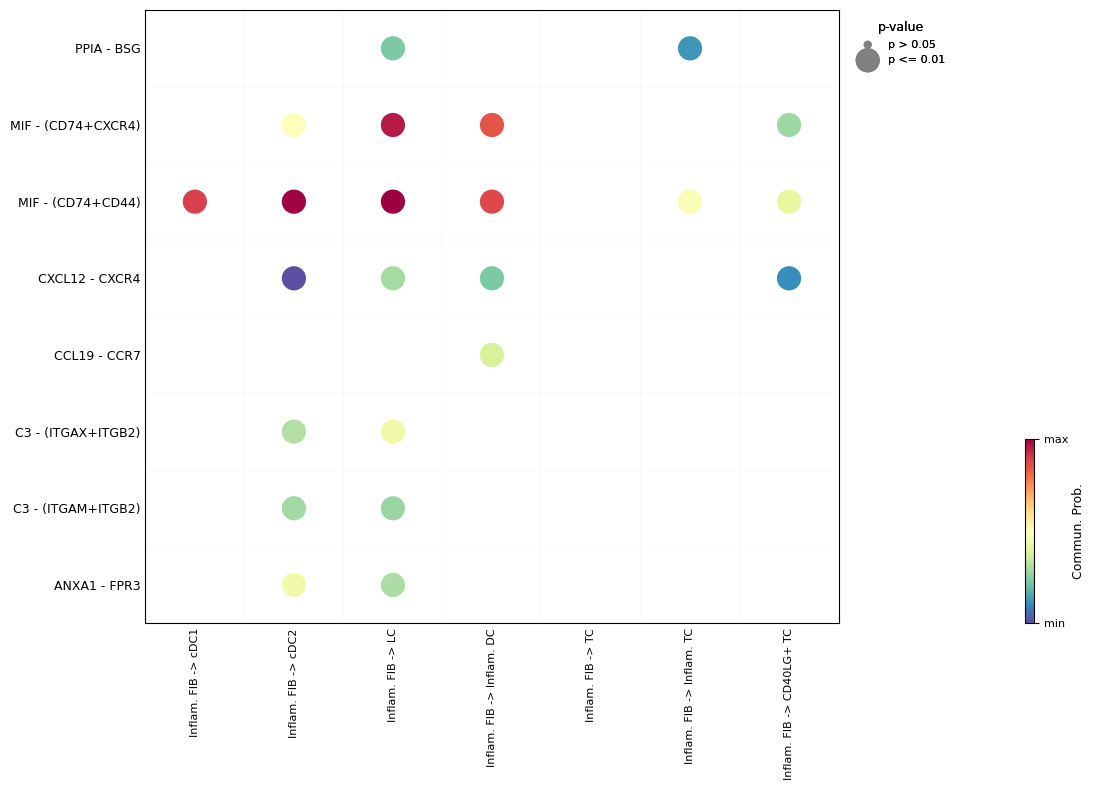

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\06_bubble_CCL_CXCL.png


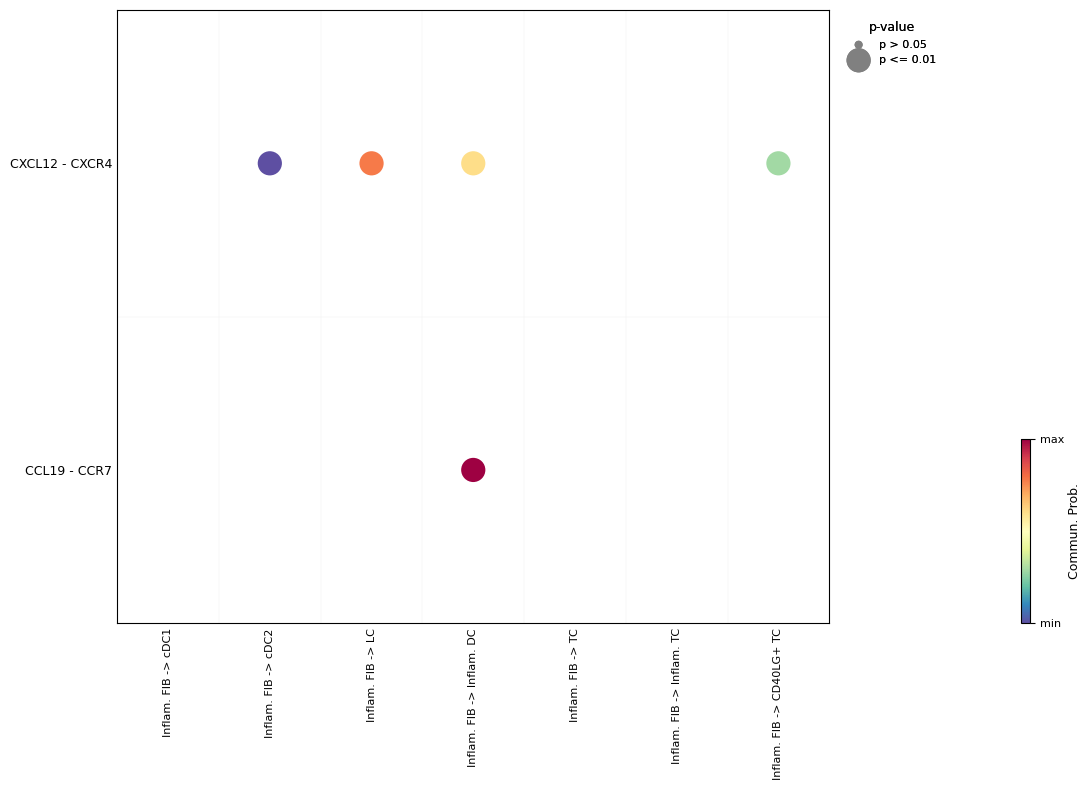

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\06_bubble_CCL_CXCL_FGF.png


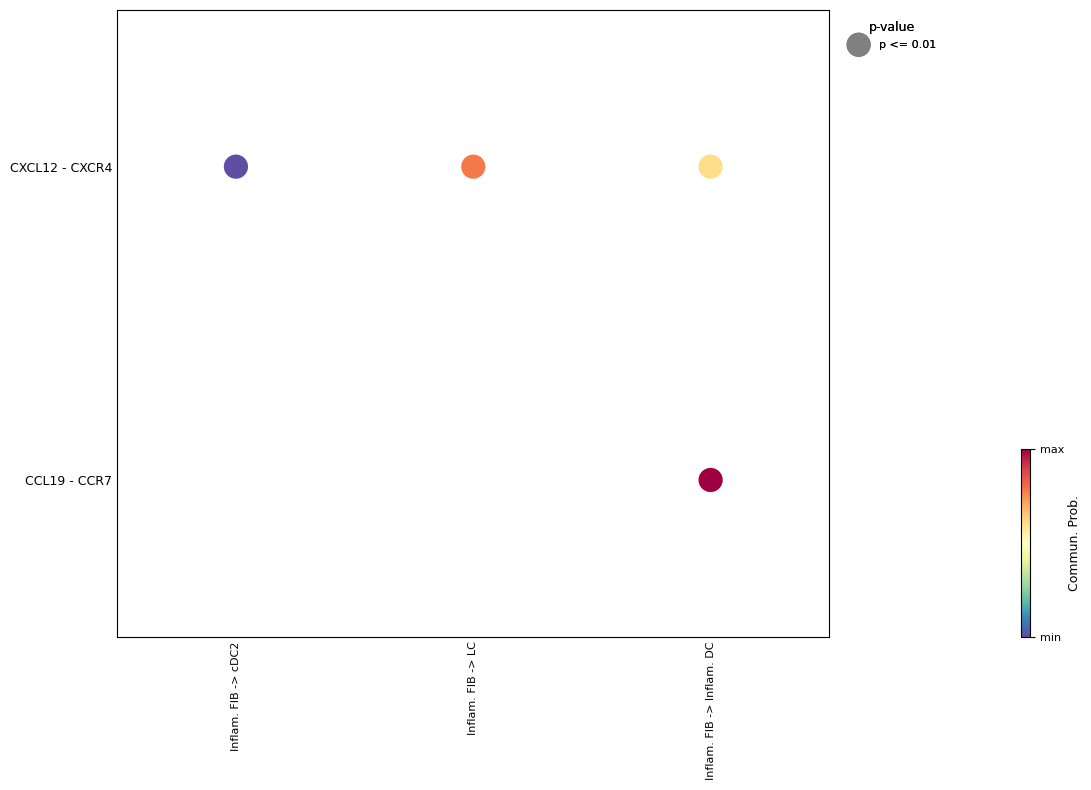

In [13]:
# --- Bubble plots ---

# Source R vignette positions: APOE+ FIB through NKT in the order above.
# Use Python zero-based slices to select the matching cell-group names.
src_4 = [r_cell_levels[3]]
tgt_5_11 = r_cell_levels[4:11]
src_3_4 = r_cell_levels[2:4]
tgt_5_8 = r_cell_levels[4:8]

print(f"Selected source group -> {src_4}")
print(f"Selected target groups -> {tgt_5_11}")

# (1) All significant interactions from Inflam. FIB to the selected targets
fig = cc.plot_network_bubble(
    cellchat, sources_use=src_4, targets_use=tgt_5_11,
    remove_isolate=False, return_fig=True)
save_fig(fig, "06_bubble_src4_tgt5to11.png")

# (2) CCL + CXCL pathways
fig = cc.plot_network_bubble(
    cellchat, sources_use=src_4, targets_use=tgt_5_11,
    signaling=["CCL", "CXCL"], remove_isolate=False, return_fig=True)
save_fig(fig, "06_bubble_CCL_CXCL.png")

# (3) Enriched L-R pairs from CCL, CXCL, FGF pathways for the selected groups
pair_lr_use = cc.extract_enriched_lr(cellchat, signaling=["CCL", "CXCL", "FGF"])
fig = cc.plot_network_bubble(
    cellchat, sources_use=src_3_4, targets_use=tgt_5_8,
    pair_lr_use=pair_lr_use, remove_isolate=True, return_fig=True)
save_fig(fig, "06_bubble_CCL_CXCL_FGF.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\07_chord_gene_from_InflamFIB.png


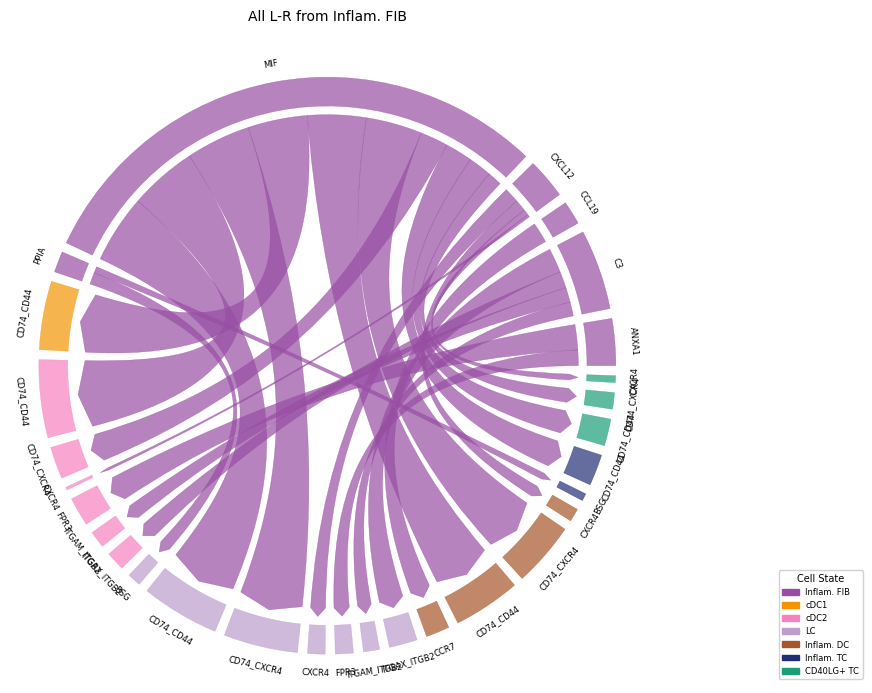

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\07_chord_gene_to_InflamDC.png


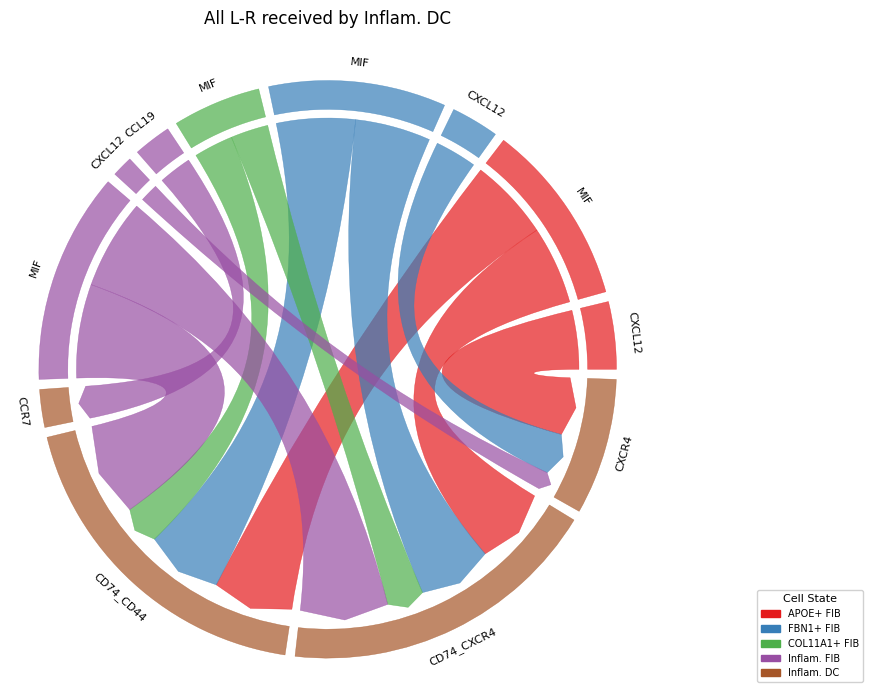

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\07_chord_gene_CCL_CXCL.png


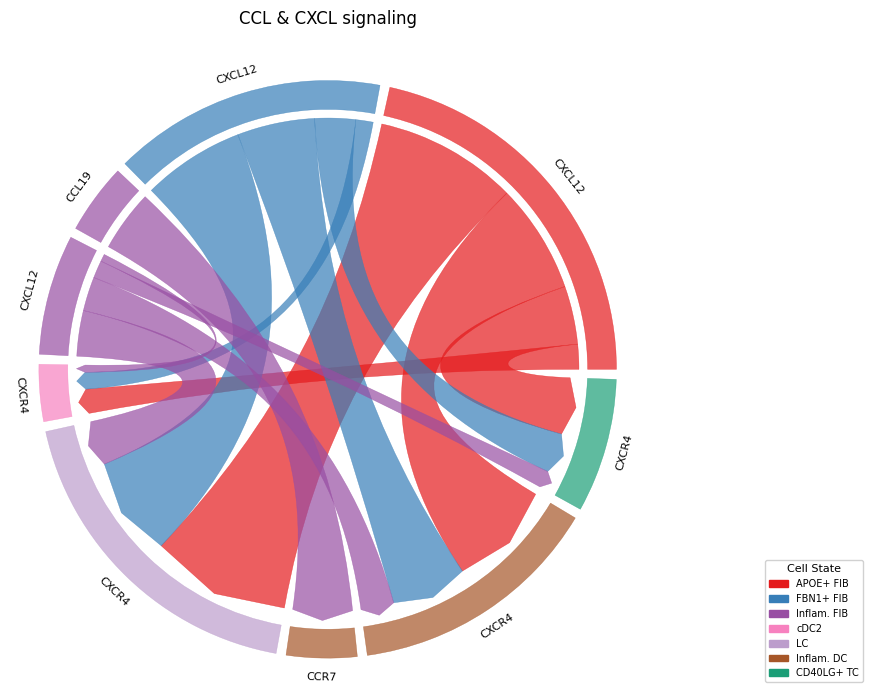

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\07_chord_gene_pathway_network.png


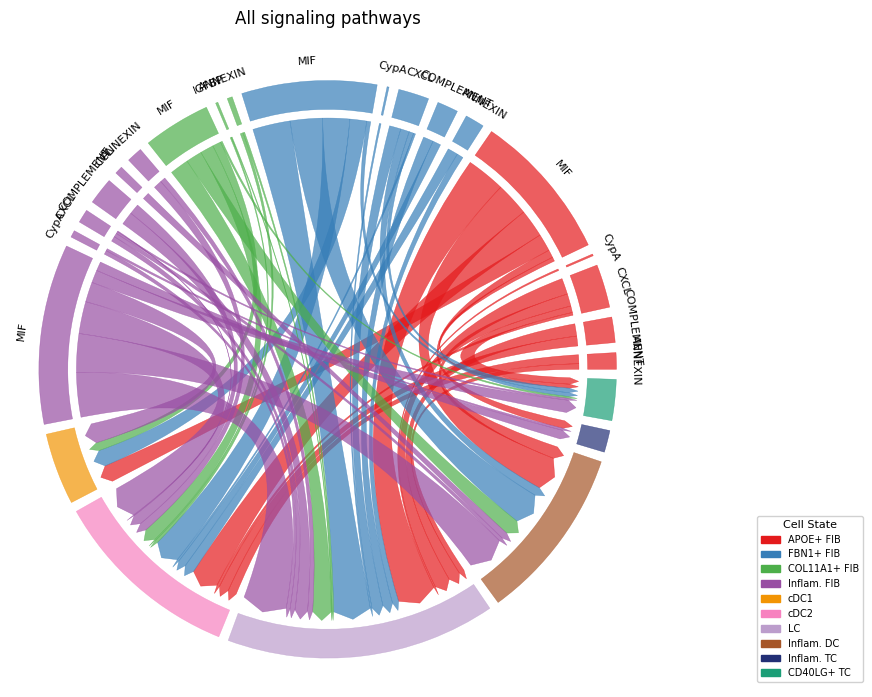

In [14]:
#  Chord gene diagrams

# R levels: 1:4 = APOE+ FIB, FBN1+ FIB, COL11A1+ FIB, Inflam. FIB
#            5:11 = cDC1, cDC2, LC, Inflam. DC, TC, Inflam. TC, CD40LG+ TC
#            8 = Inflam. DC
src_1_4 = ["APOE+ FIB", "FBN1+ FIB", "COL11A1+ FIB", "Inflam. FIB"]
tgt_5_11 = ["cDC1", "cDC2", "LC", "Inflam. DC", "TC", "Inflam. TC", "CD40LG+ TC"]
tgt_8 = ["Inflam. DC"]

# (1) All interactions sending from Inflam. FIB
fig = cc.plot_network_chord_gene(
    cellchat, sources_use=["Inflam. FIB"], targets_use=tgt_5_11,
    title_name="All L-R from Inflam. FIB", font_size=6, return_fig=True)
save_fig(fig, "07_chord_gene_from_InflamFIB.png")

# (2) All interactions received by Inflam. DC
fig = cc.plot_network_chord_gene(
    cellchat, sources_use=src_1_4, targets_use=tgt_8,
    title_name="All L-R received by Inflam. DC", return_fig=True)
save_fig(fig, "07_chord_gene_to_InflamDC.png")

# (3) CCL + CXCL signaling from sources 1:4 to targets 5:11
fig = cc.plot_network_chord_gene(
    cellchat, sources_use=src_1_4, targets_use=tgt_5_11,
    signaling=["CCL", "CXCL"], title_name="CCL & CXCL signaling", return_fig=True)
save_fig(fig, "07_chord_gene_CCL_CXCL.png")

# (4) Pathway-level (slot_name="pathway_network") from sources 1:4 to targets 5:11
fig = cc.plot_network_chord_gene(
    cellchat, sources_use=src_1_4, targets_use=tgt_5_11,
    slot_name="pathway_network", title_name="All signaling pathways", return_fig=True)
save_fig(fig, "07_chord_gene_pathway_network.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\08_geneExpr_CXCL_violin.png


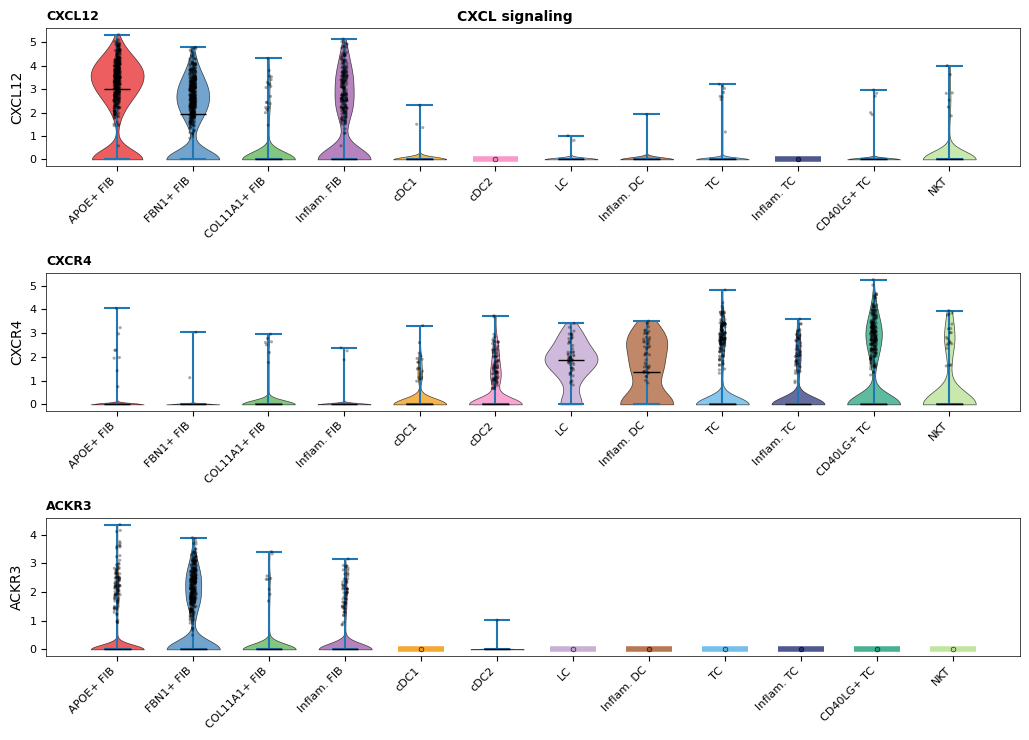

  Part III elapsed: 7.9 s


In [15]:
#  Violin plot of signaling gene expression
for pw in pathways_show:
    safe = pw.replace(" ", "_")
    fig = cc.plot_gene_expression(
        cellchat, signaling=pw, enriched_only=True, plot_type="violin", return_fig=True)
    save_fig(fig, f"08_geneExpr_{safe}_violin.png")

elapsed = time.time() - ptm
print(f"  Part III elapsed: {elapsed:.1f} s")

---
## Part IV: Systems Analysis of Cell-Cell Communication Network

Network centrality, signaling role identification, global communication patterns (NMF), and manifold learning.

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\09_centrality_network_CXCL.png


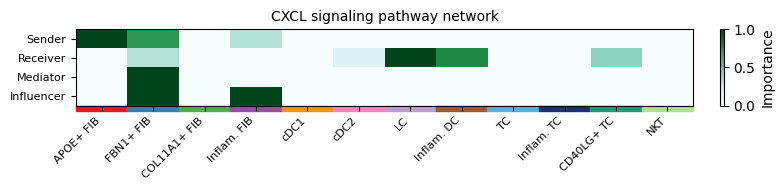

In [16]:
ptm = time.time()

#  Compute network centrality
cellchat = cc.compute_network_centrality(cellchat, slot_name="pathway_network")

#  Centrality heatmap per pathway
for pw in pathways_show:
    safe = pw.replace(" ", "_")
    fig = cc.net_analysis_signaling_role_network(cellchat, signaling=pw, return_fig=True)
    save_fig(fig, f"09_centrality_network_{safe}.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\10_role_scatter_all.png


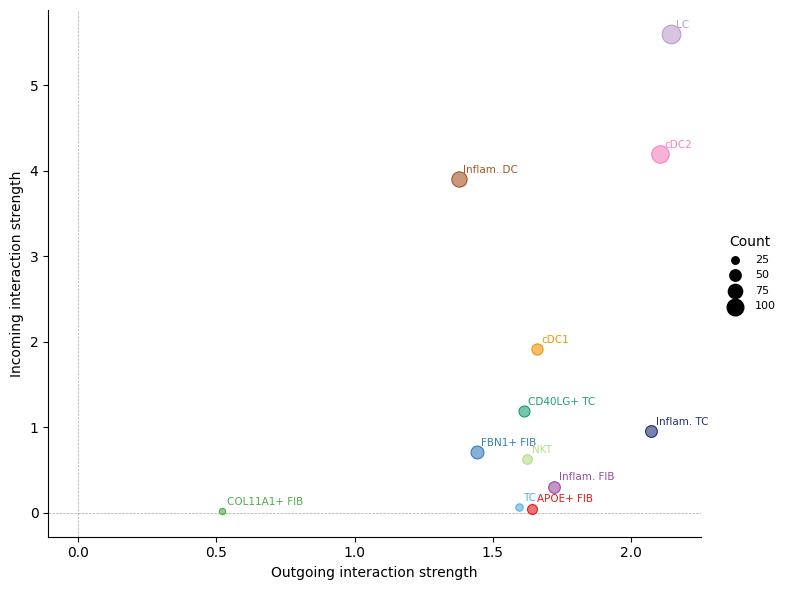

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\10_role_scatter_subset.png


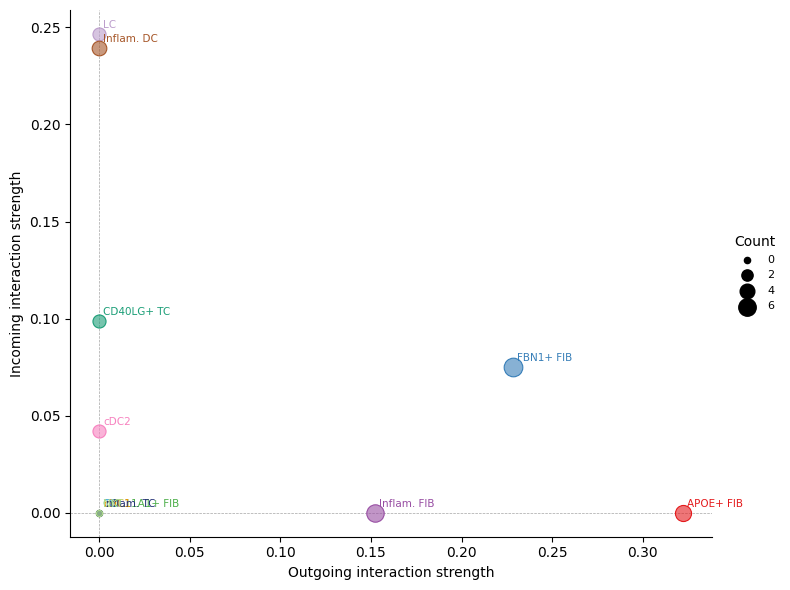

In [17]:
#  2D scatter: dominant senders and receivers

# All signaling pathways
fig = cc.net_analysis_signaling_role_scatter(cellchat, return_fig=True)
save_fig(fig, "10_role_scatter_all.png")

# Specific pathways (matches R: signaling=c("CXCL","CCL"))
fig = cc.net_analysis_signaling_role_scatter(cellchat, signaling=["CXCL", "CCL"], return_fig=True)
save_fig(fig, "10_role_scatter_subset.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\11_role_heatmap_outgoing.png


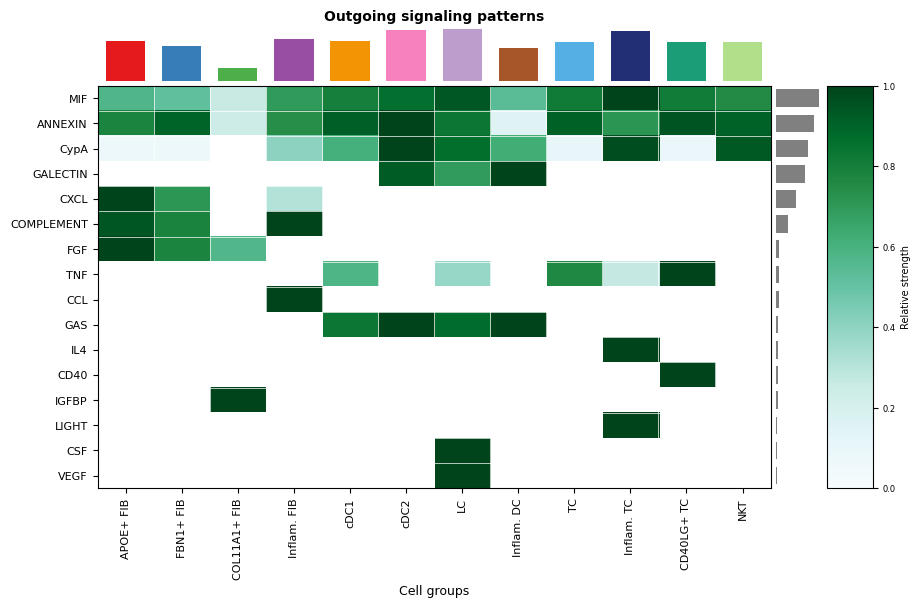

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\11_role_heatmap_incoming.png


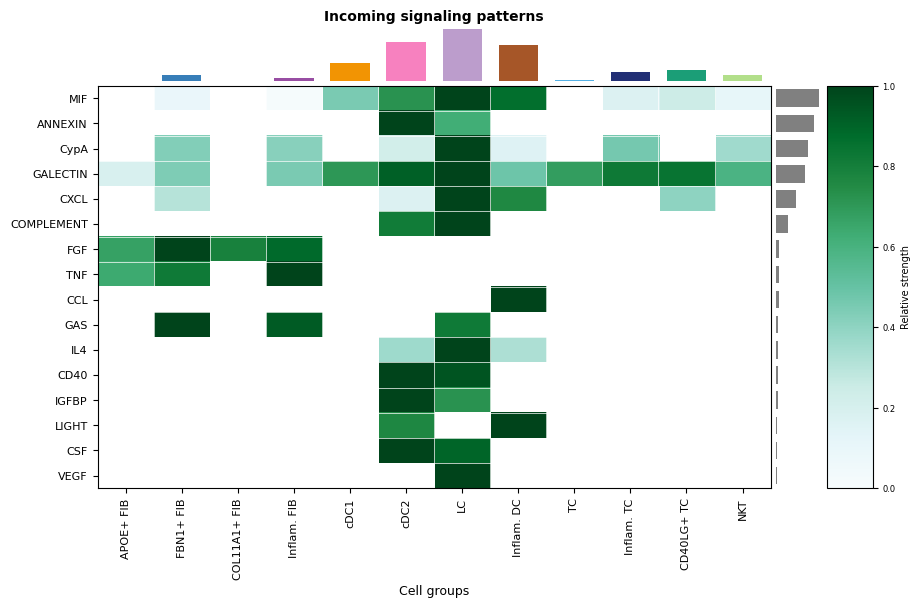

In [18]:
#  Signaling role heatmap

fig = cc.net_analysis_signaling_role_heatmap(cellchat, pattern="outgoing", return_fig=True)
save_fig(fig, "11_role_heatmap_outgoing.png")

fig = cc.net_analysis_signaling_role_heatmap(cellchat, pattern="incoming", return_fig=True)
save_fig(fig, "11_role_heatmap_incoming.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\12a_selectK_outgoing.png


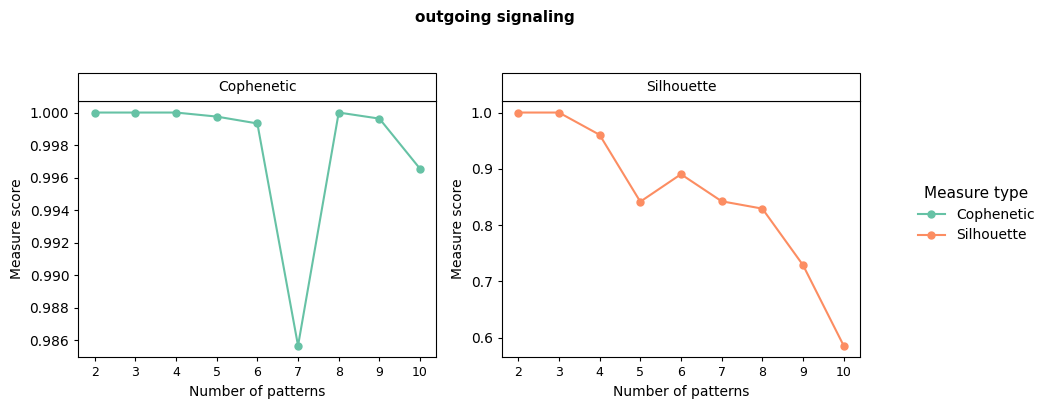

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\12b_pattern_heatmap_outgoing.png


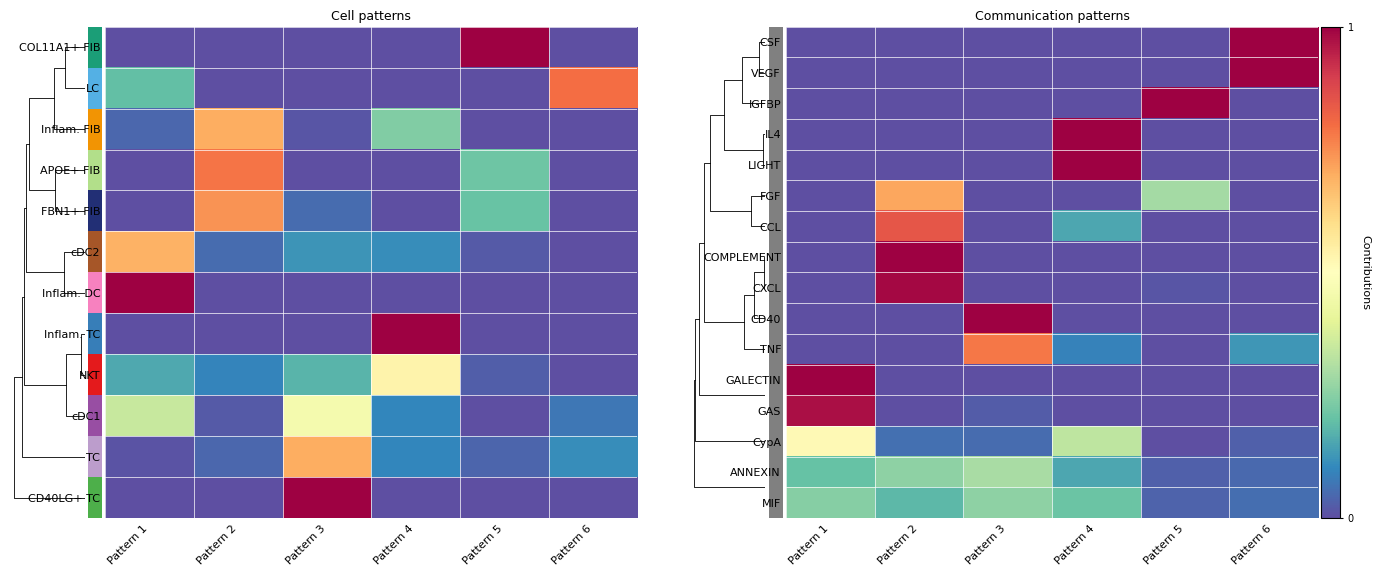

OSError: Could not save figure to 'E:\\Jin\\cellchat.python_new\\tutorial\\figures_vignette\\12b_river_outgoing.png': OSError: [Errno 22] Invalid argument: 'E:\\Jin\\cellchat.python_new\\tutorial\\figures_vignette\\12b_river_outgoing.png'

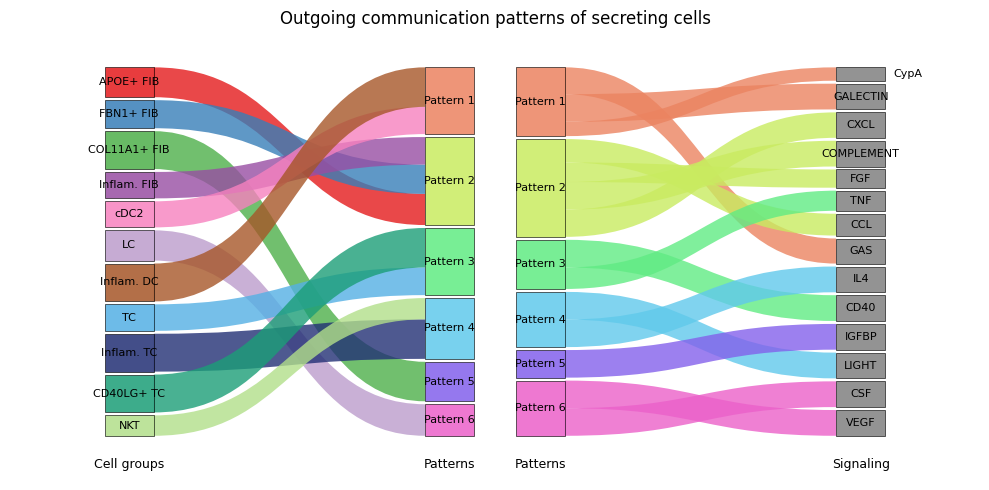

In [19]:
#  Identify global communication patterns: outgoing

result_k = cc.select_k(cellchat, pattern="outgoing", slot_name="pathway_network")
if isinstance(result_k, dict):
    k_data = {
        "k": result_k.get("k_range", result_k.get("k", [])),
        "cophenetic": result_k.get("cophenetic", []),
        "silhouette": result_k.get("silhouette", []),
    }
    fig = cc.plot_select_k(k_data, pattern="outgoing", return_fig=True)
    save_fig(fig, "12a_selectK_outgoing.png")

n_patterns_out = 6  # Adjust based on selectK results
cellchat = cc.identify_communication_patterns(cellchat, pattern="outgoing", k=n_patterns_out, slot_name="pathway_network")

fig = cc.plot_analysis_pattern_heatmap(cellchat, pattern="outgoing", return_fig=True)
save_fig(fig, "12b_pattern_heatmap_outgoing.png")

fig = cc.plot_analysis_river(cellchat, pattern="outgoing", return_fig=True)
save_fig(fig, "12b_river_outgoing.png")

fig = cc.plot_analysis_dot(cellchat, pattern="outgoing", return_fig=True)
save_fig(fig, "12c_dot_outgoing.png")

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\12a_selectK_incoming.png


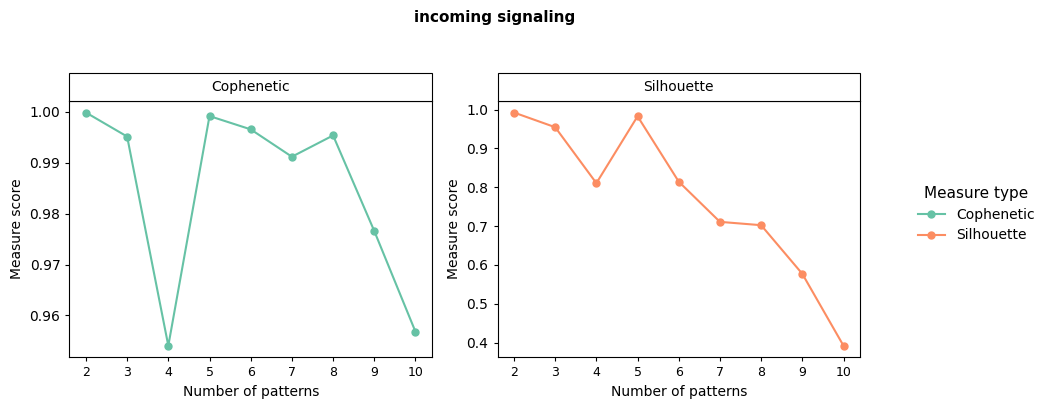

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\12d_river_incoming.png


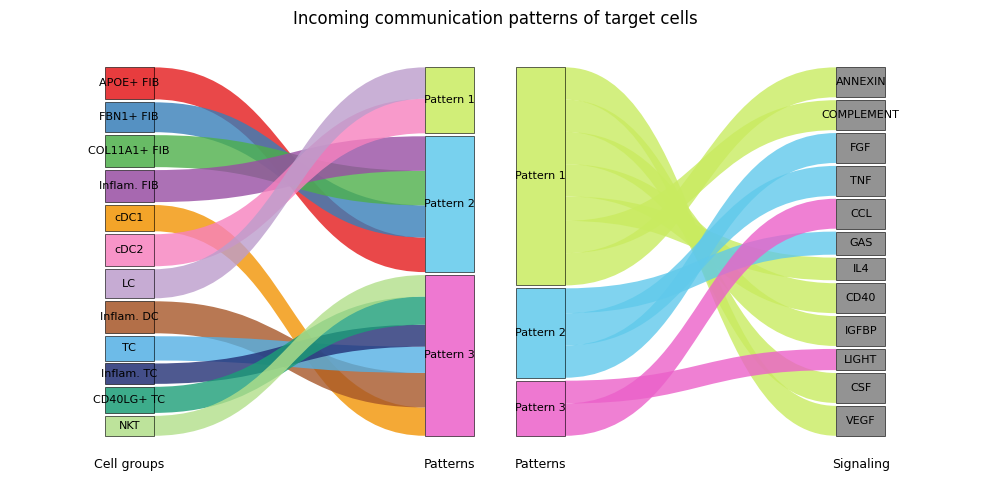

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\12e_dot_incoming.png


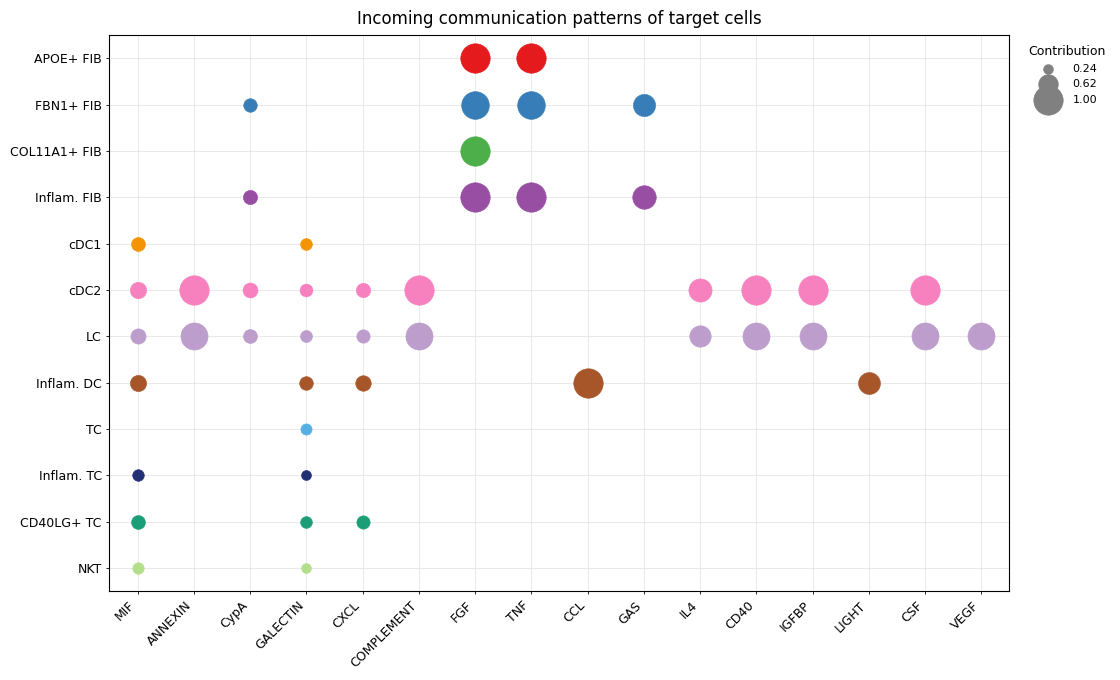

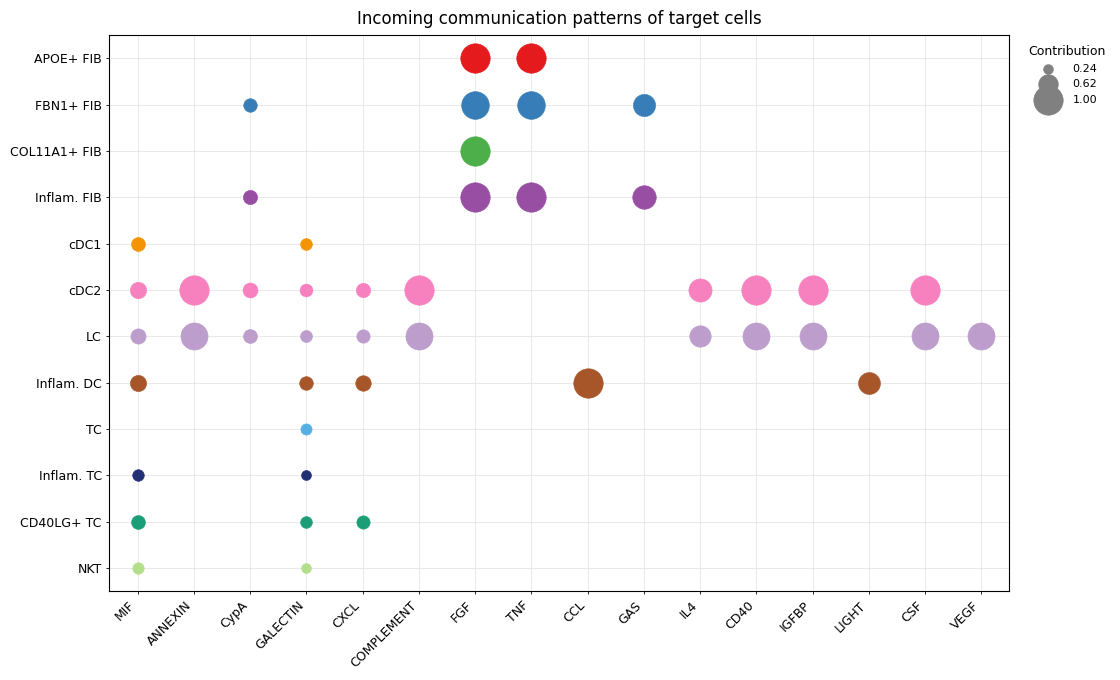

In [ ]:
#  Identify global communication patterns: incoming

result_k = cc.select_k(cellchat, pattern="incoming", slot_name="pathway_network")
if isinstance(result_k, dict):
    k_data = {
        "k": result_k.get("k_range", result_k.get("k", [])),
        "cophenetic": result_k.get("cophenetic", []),
        "silhouette": result_k.get("silhouette", []),
    }
    fig = cc.plot_select_k(k_data, pattern="incoming", return_fig=True)
    save_fig(fig, "12a_selectK_incoming.png")

n_patterns_in = 3  # Adjust based on selectK results
cellchat = cc.identify_communication_patterns(cellchat, pattern="incoming", k=n_patterns_in, slot_name="pathway_network")

fig = cc.plot_analysis_river(cellchat, pattern="incoming", return_fig=True)
save_fig(fig, "12d_river_incoming.png")

fig = cc.plot_analysis_dot(cellchat, pattern="incoming", return_fig=True)
save_fig(fig, "12e_dot_incoming.png")

## Manifold and classification learning analysis of signaling networks

CellChat quantifies the similarity among significant signaling pathways and then classifies them in a learned 2D manifold. This follows the R vignette exactly:

- **Functional similarity** compares whether pathways use similar sender and receiver cell groups; it is appropriate when the cell population composition is the same.
- **Structural similarity** compares the overall signaling network topology without requiring the same sender/receiver identities.

Functional clustering k: None
Functional similarity checksum: sum=22.945729505546, norm=4.224013144717
Functional similarity row sums: [1.813487, 1.681705, 1.910523, 1.572852, 1.610671, 1.593561, 1.011429, 1.271569, 1.009524, 1.513063, 1.425823, 1.018257, 1.015152, 1.4, 1.555439, 1.542677]
Functional embedding method: umap-learn
Functional embedding init: None
Functional embedding n_epochs: None
Functional embedding coordinates:
  MIF: (10.594456, 15.307286)
  ANNEXIN: (9.720226, 15.336534)
  CypA: (10.370247, 14.548558)
  GALECTIN: (11.205957, 14.694171)
  CXCL: (10.240123, 16.315449)
  COMPLEMENT: (9.561378, 16.100700)
  FGF: (13.213226, 12.249325)
  TNF: (11.206212, 13.965546)
  CCL: (12.779323, 11.767078)
  GAS: (11.699204, 13.356506)
  IL4: (14.089672, 12.926236)
  CD40: (13.353849, 11.460117)
  IGFBP: (13.962514, 11.721184)
  LIGHT: (14.612494, 12.475184)
  CSF: (12.634027, 12.814010)
  VEGF: (12.105281, 12.267755)
Functional similarity: 16 embedded pathways, 5 signaling groups
F

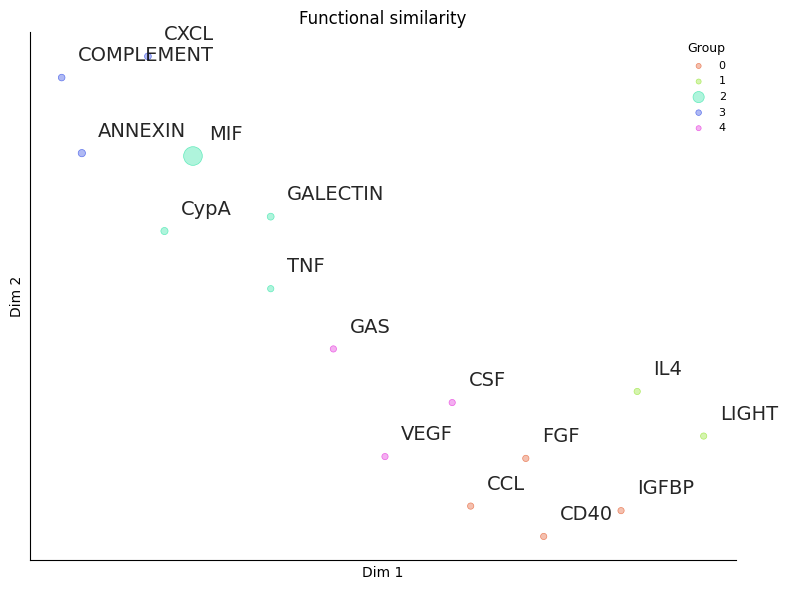

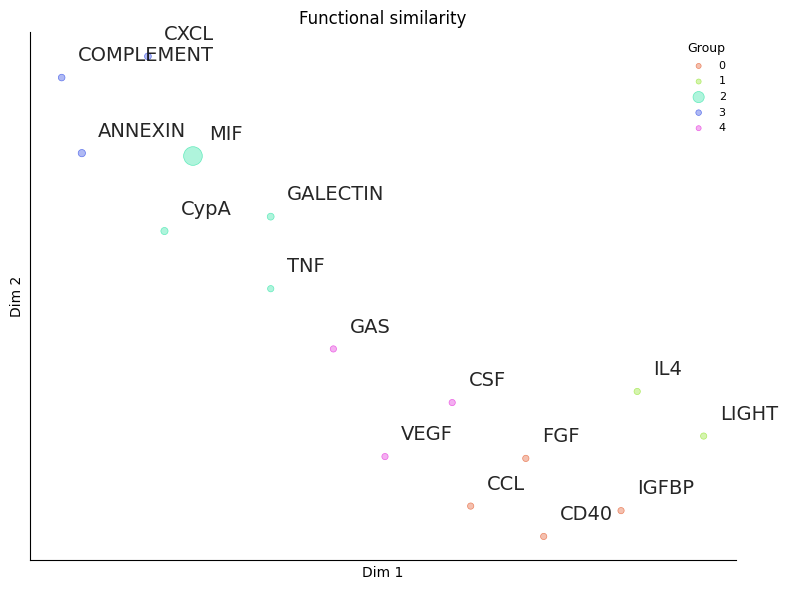

In [ ]:
# --- Identify signaling groups based on functional similarity ---
#   cellchat <- compute_network_similarity(cellchat, type = "functional")
#   cellchat <- embed_network(cellchat, type = "functional")
#   cellchat <- cluster_network(cellchat, type = "functional")
#   plot_network_embedding(cellchat, type = "functional", label.size = 3.5)

cellchat = cc.compute_network_similarity(cellchat, type="functional")
cellchat = cc.embed_network(cellchat, type="functional")
cellchat = cc.cluster_network(cellchat, type="functional")

sim_fun = cellchat.pathway_network["similarity"]["functional"]
print(f"Functional clustering k: {sim_fun.get('k')}")
dr_fun = np.asarray(sim_fun["dr"]["single"])
pathways_fun = list(sim_fun.get("pathways", []))
groups_fun = list(sim_fun["group"]["single"])
matrix_fun = np.asarray(sim_fun["matrix"]["single"], dtype=float)
print(
    "Functional similarity checksum: "
    f"sum={matrix_fun.sum():.12f}, norm={np.linalg.norm(matrix_fun):.12f}"
)
print("Functional similarity row sums:", np.round(matrix_fun.sum(axis=1), 6).tolist())
print(f"Functional embedding method: {sim_fun.get('embedding_method', 'unknown')}")
print(f"Functional embedding init: {sim_fun.get('embedding_init', 'unknown')}")
print(f"Functional embedding n_epochs: {sim_fun.get('embedding_n_epochs', 'unknown')}")
if sim_fun.get("embedding_error"):
    print(f"Functional embedding fallback error: {sim_fun['embedding_error']}")
print("Functional embedding coordinates:")
for pathway, xy in zip(pathways_fun, dr_fun):
    print(f"  {pathway}: ({xy[0]:.6f}, {xy[1]:.6f})")

if dr_fun.shape[0] != len(pathways_fun) or dr_fun.shape[0] != len(groups_fun):
    raise ValueError(
        "Functional embedding, pathway labels, and cluster labels are not aligned: "
        f"embedding={dr_fun.shape[0]}, pathways={len(pathways_fun)}, groups={len(groups_fun)}"
    )

print(
    f"Functional similarity: {dr_fun.shape[0]} embedded pathways, "
    f"{len(set(groups_fun))} signaling groups"
)

print("Functional signaling groups:")
for group_id in sorted(set(groups_fun)):
    members = [p for p, g in zip(pathways_fun, groups_fun) if g == group_id]
    print(f"  Group {group_id}: {', '.join(members)}")

fig = cc.plot_network_embedding(
    cellchat,
    emb_type="functional",
    label_size=3.5,
    title="Functional similarity",
    return_fig=True,
)
save_fig(fig, "13_embedding_functional.png")

# As in the R vignette, the functional zoom-in plot is optional:
# fig = cc.plot_network_embedding_zoom_in(cellchat, emb_type="functional", ncol=2, return_fig=True)
# save_fig(fig, "13_embedding_functional_zoomin.png")

### Identify signaling groups based on structural similarity

Structural similarity highlights pathways with similar communication-network topology. The zoom-in plot is kept for this mode, matching the R vignette.

Structural similarity: 16 embedded pathways, 4 signaling groups
  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\14_embedding_structural.png


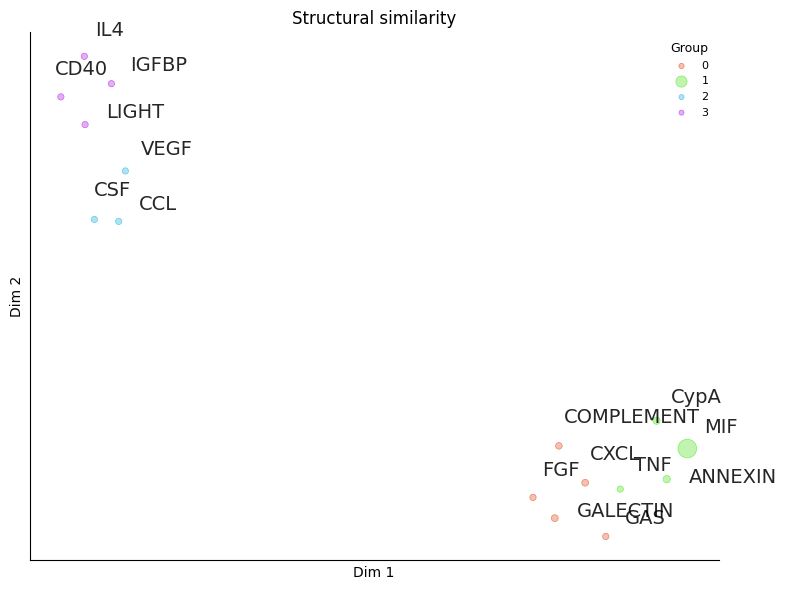

  Saved: E:\Jin\cellchat.python_new\tutorial\figures_vignette\14_embedding_structural_zoomin.png


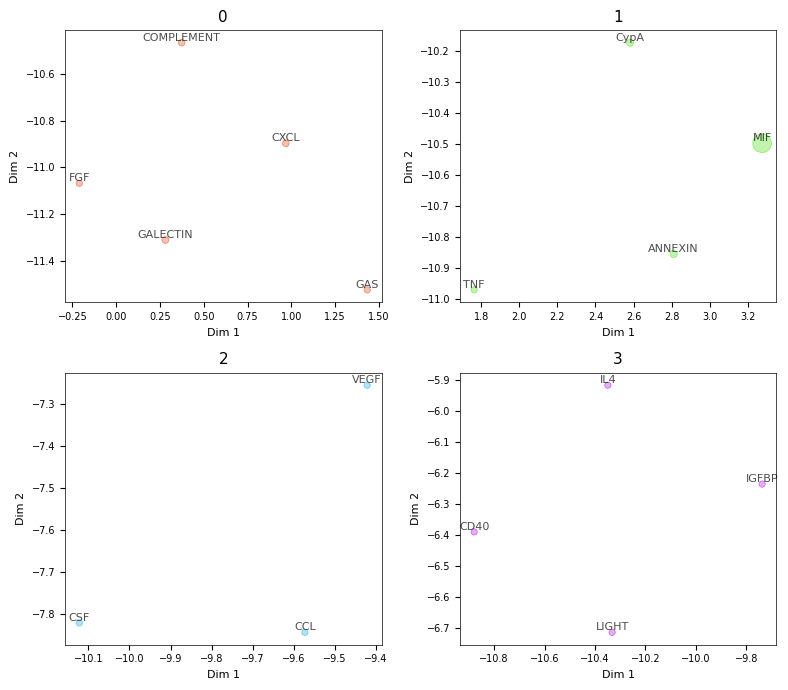

Part IV systems analysis elapsed: 981.9 s


In [ ]:
# --- Identify signaling groups based on structural similarity ---
#   cellchat <- compute_network_similarity(cellchat, type = "structural")
#   cellchat <- embed_network(cellchat, type = "structural")
#   cellchat <- cluster_network(cellchat, type = "structural")
#   plot_network_embedding(cellchat, type = "structural", label.size = 3.5)
#   plot_network_embeddingZoomIn(cellchat, type = "structural", nCol = 2)

cellchat = cc.compute_network_similarity(cellchat, type="structural")
cellchat = cc.embed_network(cellchat, type="structural")
cellchat = cc.cluster_network(cellchat, type="structural")

sim_str = cellchat.pathway_network["similarity"]["structural"]
dr_str = np.asarray(sim_str["dr"]["single"])
pathways_str = list(sim_str.get("pathways", []))
groups_str = list(sim_str["group"]["single"])

if dr_str.shape[0] != len(pathways_str) or dr_str.shape[0] != len(groups_str):
    raise ValueError(
        "Structural embedding, pathway labels, and cluster labels are not aligned: "
        f"embedding={dr_str.shape[0]}, pathways={len(pathways_str)}, groups={len(groups_str)}"
    )

print(
    f"Structural similarity: {dr_str.shape[0]} embedded pathways, "
    f"{len(set(groups_str))} signaling groups"
)

fig = cc.plot_network_embedding(
    cellchat,
    emb_type="structural",
    label_size=3.5,
    title="Structural similarity",
    return_fig=True,
)
save_fig(fig, "14_embedding_structural.png")

fig = cc.plot_network_embedding_zoom_in(
    cellchat,
    emb_type="structural",
    ncol=2,
    return_fig=True,
)
save_fig(fig, "14_embedding_structural_zoomin.png")

execution_time = time.time() - ptm
print(f"Part IV systems analysis elapsed: {execution_time:.1f} s")

In [ ]:
#  Save CellChat object
from pathlib import Path

output_dir = Path.cwd().resolve()
output_pkl = output_dir / "cellchat_humanSkin_LS.pkl"
with output_pkl.open("wb") as f:
    pickle.dump(cellchat, f)
print(f"CellChat object saved to: {output_pkl}")

#  Export significant interactions to CSV
df_net = cc.subset_communication(cellchat)
csv_out = output_dir / "cellchat_humanSkin_LS_interactions.csv"
df_net.to_csv(csv_out, index=False)
print(f"Interactions saved to: {csv_out}")
print(f"Total interactions: {len(df_net)}")

elapsed_total = time.time() - ptm_total
print(f"\nTotal pipeline elapsed: {elapsed_total:.1f} s ({elapsed_total/60:.1f} min)")

CellChat object saved to: E:\Jin\cellchat.python_new\tutorial\cellchat_humanSkin_LS.pkl
Interactions saved to: E:\Jin\cellchat.python_new\tutorial\cellchat_humanSkin_LS_interactions.csv
Total interactions: 367

Total pipeline elapsed: 1424.7 s (23.7 min)
